In [1]:
import numpy as np
from PyEMD import EMD
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from scipy.io import wavfile
import pandas as pd

# Step 1: Empirical Mode Decomposition (EMD)
def perform_emd(signal):
    """ Decompose the signal using EMD into IMFs """
    emd = EMD()
    imfs = emd(signal)
    return imfs

# Step 2: Hilbert Transform to get instantaneous frequency and amplitude
def hilbert_transform(imf):
    """ Apply the Hilbert Transform to an IMF """
    analytic_signal = hilbert(imf)
    amplitude_envelope = np.abs(analytic_signal)
    instantaneous_phase = np.unwrap(np.angle(analytic_signal))
    instantaneous_frequency = np.diff(instantaneous_phase) / (2.0 * np.pi)
    
    return amplitude_envelope, instantaneous_frequency

# Step 3: Hilbert-Huang Transform (HHT)
def hht(signal):
    """ Perform HHT by applying Hilbert Transform to the IMFs obtained from EMD """
    imfs = perform_emd(signal)
    amplitudes = []
    frequencies = []
    
    for imf in imfs:
        amp, freq = hilbert_transform(imf)
        amplitudes.append(amp)
        frequencies.append(freq)
    
    return imfs, amplitudes, frequencies

# Example usage
if __name__ == "__main__":
    # load signal
    sample_rate, audio_signal = wavfile.read('../pd_model/PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_014.wav')

    # If the audio has two channels (stereo), take one channel
    if len(audio_signal.shape) > 1:
        audio_signal = audio_signal[:, 0]

    # Normalize the signal
    signal = audio_signal / np.max(np.abs(audio_signal))
    
    # Perform HHT
    imfs, amplitudes, frequencies = hht(signal)
    
    amp_features = []
    for i, amp in enumerate(amplitudes):
        mean = np.mean(amp)
        median = np.median(amp)
        std = np.std(amp)
        mn = np.min(amp)
        mx = np.max(amp)
        skewness = pd.Series(amp).skew()
        kurtosis = pd.Series(amp).kurtosis()
        amp_features.extend([mean, median, std, mn, mx, skewness, kurtosis])

    freq_features = []
    for i, freq in enumerate(frequencies):
        mean = np.mean(freq)
        median = np.median(freq)
        std = np.std(freq)
        mn = np.min(freq)
        mx = np.max(freq)
        skewness = pd.Series(freq).skew()
        kurtosis = pd.Series(freq).kurtosis()
        freq_features.extend([mean, median, std, mn, mx, skewness, kurtosis])

    amp_columns = [f'{stat}HIL_AMP_{i}' for i in range(len(amp_features) // 7) for stat in ['mean', 'median', 'std', 'min', 'max', 'skewness', 'kurtosis']]
    freq_columns = [f'{stat}HIL_FREQ_{i}' for i in range(len(freq_features) // 7) for stat in ['mean', 'median', 'std', 'min', 'max', 'skewness', 'kurtosis']]


    print(np.array(amp_features).shape)
    print(np.array(freq_features).shape)
            

(119,)
(119,)


In [5]:
import numpy as np
import librosa
from scipy.fftpack import dct

def frame_signal(signal, frame_size, hop_size, sr):
    """Frame the signal with a specific frame size and hop size"""
    return librosa.util.frame(signal, frame_length=frame_size, hop_length=hop_size).T

def compute_instantaneous_energy(frames):
    """Compute the energy for each frame"""
    return np.sum(frames ** 2, axis=1)

def compute_energy_deviation(energy):
    """Compute the deviation of energy from frame to frame"""
    return np.diff(energy)

def mel_filter_bank(sr, n_fft, n_mels=26):
    """ Create a Mel filter bank. """
    return librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels)

def energy_deviation_to_cepstral(energy_deviation, sr, n_mels=26, n_fft=2048):
    """ Convert energy deviation to cepstral coefficients """
    # Step 1: Compute the FFT of the energy deviation
    spectrum = np.abs(np.fft.fft(energy_deviation, n=n_fft))[:n_fft//2+1]
    
    # Step 2: Apply Mel-filter bank
    mel_fb = mel_filter_bank(sr, n_fft, n_mels)
    mel_spectrum = np.dot(mel_fb, spectrum)
    
    # Step 3: Take the logarithm of the Mel spectrum
    log_mel_spectrum = np.log(mel_spectrum + 1e-8)  # Avoid log(0)
    
    # Step 4: Apply Discrete Cosine Transform (DCT)
    cepstral_coeffs = dct(log_mel_spectrum, type=2, norm='ortho')
    
    return cepstral_coeffs[:13]  # Typically keep 13 coefficients

def compute_iedcc(signal, sr, frame_size=1024, hop_size=512, n_mels=26, n_fft=2048):
    """ Compute IEDCC for a given signal """
    # Step 1: Frame the signal
    frames = frame_signal(signal, frame_size, hop_size, sr)
    
    # Step 2: Compute instantaneous energy
    energy = compute_instantaneous_energy(frames)
    
    # Step 3: Compute energy deviation
    energy_deviation = compute_energy_deviation(energy)
    
    # Step 4: Compute cepstral coefficients from energy deviation
    iedcc = energy_deviation_to_cepstral(energy_deviation, sr, n_mels, n_fft)
    
    return iedcc

# Example usage
if __name__ == "__main__":
    # Load an example audio signal
    signal, sr = librosa.load('../pd_model/PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_014.wav', sr=None)

    # Compute IEDCC
    iedcc = compute_iedcc(signal, sr)
    print("IEDCC:", iedcc)
    print(len(iedcc))


IEDCC: [ 8.83909891 -0.64011132 -2.51193127  1.01005901 -0.27674547 -0.07962724
 -0.69032311  0.1556608  -0.58601609  0.34937833 -0.53681788  0.11724872
  0.93213825]
13


In [10]:
import numpy as np
import librosa
from scipy.fftpack import dct
from PyEMD import EMD
import matplotlib.pyplot as plt
from scipy.io import wavfile
import json
import pandas as pd


with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)

data_dir = './PD/AudioKoreaDrKim'
def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths

def mel_filter_bank(sr, n_fft, n_mels=26):
    """ Create a Mel filter bank. """
    return librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels)

def imf_to_cepstral(imf, sr, n_mels=26, n_fft=2048):
    """ Convert a single IMF to cepstral coefficients """
    # Step 1: Compute the FFT of the IMF
    spectrum = np.abs(np.fft.fft(imf, n=n_fft))[:n_fft//2+1]
    
    # Step 2: Apply Mel-filter bank
    mel_fb = mel_filter_bank(sr, n_fft, n_mels)
    mel_spectrum = np.dot(mel_fb, spectrum)
    
    # Step 3: Take the logarithm of the Mel spectrum
    log_mel_spectrum = np.log(mel_spectrum + 1e-8)  # Avoid log(0)
    
    # Step 4: Apply Discrete Cosine Transform (DCT)
    cepstral_coeffs = dct(log_mel_spectrum, type=2, norm='ortho')
    
    return cepstral_coeffs[:13]  # Typically keep 13 coefficients

feature_names = ["imfcc(17,13)",
                 ]

input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat)
    for path in paths:
        print(path[-7:-4])

        sr, audio_signal = wavfile.read(path)

        # If the audio has two channels (stereo), take one channel
        if len(audio_signal.shape) > 1:
            audio_signal = audio_signal[:, 0]

        # Normalize the signal
        signal = audio_signal / np.max(np.abs(audio_signal))
        # Perform EMD to get IMFs
        emd = EMD()
        imfs = emd(signal)

        imfccs = []
        for imf in imfs[:17]:
            imfccs.append(imf_to_cepstral(imf, sr))

        # Convert to numpy array for easier manipulation
        imfccs = np.array(imfccs)

        print(imfccs.shape)
        imfcc_features = imfccs.flatten().tolist()
        print(len(imfcc_features))
        imfcc_columns = [f'imfcc_{imf_id}_{mfcc_id}' for imf_id in range(1, 18) for mfcc_id in range(1, 14)]
        features_df = pd.DataFrame([imfcc_features], columns=imfcc_columns)
        input_embeddings[pat][path[-7:-4]] = features_df.to_dict()
        for key, val in input_embeddings[pat][path[-7:-4]].items():
            input_embeddings[pat][path[-7:-4]][key] = val[0]

        print(input_embeddings[pat][path[-7:-4]])

# Get the IMFCCs for each IMF
# imfccs = []
# for imf in imfs:
#     imfccs.append(imf_to_cepstral(imf, sr))

# # Convert to numpy array for easier manipulation
# imfccs = np.array(imfccs)

# # Plot IMFCCs
# plt.imshow(imfccs.T, aspect='auto', origin='lower')
# plt.title('IMFCCs')
# plt.xlabel('IMF index')
# plt.ylabel('Cepstral Coefficient')
# plt.colorbar()
# plt.show()

# print(imfccs.flatten().tolist())
with open("imfcc_features.json", "w") as fp:
    json.dump(input_embeddings, fp)


1-001
017
(17, 13)
221
{'imfcc_1_1': -48.361485734007545, 'imfcc_1_2': -1.7788340207176194, 'imfcc_1_3': 1.1888223045284465, 'imfcc_1_4': -0.5220851123631944, 'imfcc_1_5': 0.12363368627656274, 'imfcc_1_6': -0.21443905488910442, 'imfcc_1_7': -0.09265867523725728, 'imfcc_1_8': 0.016714730919202583, 'imfcc_1_9': -0.15605520216490004, 'imfcc_1_10': -0.07223493096284678, 'imfcc_1_11': 0.019243911398326118, 'imfcc_1_12': -0.022827621437825085, 'imfcc_1_13': 0.1766139515422463, 'imfcc_2_1': -51.12555424371768, 'imfcc_2_2': -2.2220212812192615, 'imfcc_2_3': -0.16616003069841445, 'imfcc_2_4': 0.8064210086378827, 'imfcc_2_5': -1.262867560851494, 'imfcc_2_6': 0.862203592957572, 'imfcc_2_7': -0.749051873049064, 'imfcc_2_8': 0.3076441592317863, 'imfcc_2_9': -0.33284969633875744, 'imfcc_2_10': 0.10714401827425465, 'imfcc_2_11': -0.16017347885602115, 'imfcc_2_12': 0.283789626730081, 'imfcc_2_13': 0.23508689453570852, 'imfcc_3_1': -52.56080887818132, 'imfcc_3_2': -0.5254361400938781, 'imfcc_3_3': -2.8

In [3]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, find_peaks
import json

# Step 1: Load Audio File and Preprocessing
# audio_file = '../pd_model/PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_015.wav'  # Replace with your actual file path
with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)

data_dir = './PD/AudioKoreaDrKim'
def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths

def extract_glottal_features(audio_file):
    y, sr = librosa.load(audio_file, sr=None)

    # Plot the audio signal
    # plt.figure(figsize=(10, 4))
    # plt.plot(y)
    # plt.title("Speech Signal")
    # plt.xlabel("Time (samples)")
    # plt.ylabel("Amplitude")
    # plt.show()

    # Step 2: Estimate the Glottal Flow using LPC
    def lpc_coefficients(y, order=12):
        """Compute LPC coefficients."""
        return librosa.lpc(y, order=order)

    # Get LPC coefficients
    lpc_order = 16  # Typically 8-16 works for speech
    lpc = lpc_coefficients(y, lpc_order)

    # Invert the filter to estimate the glottal waveform
    glottal_flow = lfilter([1], lpc, y)

    # Plot the estimated glottal flow waveform
    # plt.figure(figsize=(10, 4))
    # plt.plot(glottal_flow)
    # plt.title("Estimated Glottal Flow")
    # plt.xlabel("Time (samples)")
    # plt.ylabel("Amplitude")
    # plt.show()

    # Step 3: Detect Glottal Closure and Opening Instants
    # Compute the derivative of the glottal waveform
    glottal_derivative = np.diff(glottal_flow)

    # Detect the glottal closure instants (negative peaks)
    glottal_closure_peaks, _ = find_peaks(-glottal_derivative, height=0.02, distance=sr // 200)  # Example threshold

    # Detect the glottal opening instants (positive peaks)
    glottal_opening_peaks, _ = find_peaks(glottal_derivative, height=0.02, distance=sr // 200)

    # Plot the derivative with detected closure and opening instants
    # plt.figure(figsize=(10, 4))
    # plt.plot(glottal_derivative, label="Glottal Derivative")
    # plt.plot(glottal_closure_peaks, glottal_derivative[glottal_closure_peaks], "x", label="Closure Instants", markersize=10)
    # plt.plot(glottal_opening_peaks, glottal_derivative[glottal_opening_peaks], "o", label="Opening Instants", markersize=10)
    # plt.title("Glottal Derivative with Closure and Opening Instants")
    # plt.xlabel("Time (samples)")
    # plt.ylabel("Amplitude")
    # plt.legend()
    # plt.show()


    # Ensure correct pairing: Each GOI should pair with the next GCI (not the previous one)
    min_length = min(len(glottal_opening_peaks), len(glottal_closure_peaks) - 1)

    # Ensure the GOI is paired with the next GCI
    valid_gois = []
    valid_gcis = []

    for goi in glottal_opening_peaks:
        # Find the next GCI that occurs after this GOI
        next_gc_index = np.where(glottal_closure_peaks > goi)[0]
        if len(next_gc_index) > 0:
            if (len(valid_gcis) > 0 and goi < valid_gcis[-1]):
                valid_gois = valid_gois[:-1]
            else: 
                valid_gcis.append(glottal_closure_peaks[next_gc_index[0]])

            valid_gois.append(goi)

    # Convert valid_gois and valid_gcis to numpy arrays for further calculations
    valid_gois = np.array(valid_gois)
    valid_gcis = np.array(valid_gcis)
    # Calculate Glottal Period (T_cycle) = difference between consecutive GCIs
    glottal_periods = np.diff(valid_gcis) / sr  # Convert samples to time (in seconds)

    # Calculate Open Time (T_open) = difference between GOIs and GCIs
    # Ensure the number of cycles is consistent
    glottal_open_times = (valid_gcis[:-1] - valid_gois[:-1]) / sr

    # Calculate the Open Quotient for each glottal cycle where both GOIs and GCIs are present
    open_quotients = glottal_open_times / glottal_periods
    # print(open_quotients.shape)

    # Plot the glottal features: Glottal Period and Open Quotient
    # plt.figure(figsize=(10, 4))
    # plt.plot(glottal_periods, label="Glottal Period (s)")
    # plt.plot(open_quotients, label="Open Quotient")
    # plt.title("Glottal Features")
    # plt.xlabel("Glottal Cycle")
    # plt.legend()
    # plt.show()

    valid_gois = valid_gois / sr
    if len(valid_gois) == 0:
        valid_gois = np.append(valid_gois, [0], axis=0)
    mean_gois = np.mean(valid_gois)
    median_gois = np.median(valid_gois)
    stdev_gois = np.std(valid_gois)
    min_gois = np.min(valid_gois)
    max_gois = np.max(valid_gois)
    gois_features = [mean_gois, median_gois, stdev_gois, min_gois, max_gois]

    valid_gcis = valid_gcis / sr
    if len(valid_gcis) == 0:
        valid_gcis = np.append(valid_gcis, [0], axis=0)    
    mean_gcis = np.mean(valid_gcis)
    median_gcis = np.median(valid_gcis)
    stdev_gcis = np.std(valid_gcis)
    min_gcis = np.min(valid_gcis)
    max_gcis = np.max(valid_gcis)
    gcis_features = [mean_gcis, median_gcis, stdev_gcis, min_gcis, max_gcis]

    if len(open_quotients) == 0:
        open_quotients = np.append(open_quotients, [0], axis=0)
    mean_op = np.mean(open_quotients)
    median_op = np.median(open_quotients)
    stdev_op = np.std(open_quotients)
    min_op = np.min(open_quotients)
    max_op = np.max(open_quotients)
    op_features = [mean_op, median_op, stdev_op, min_op, max_op]

    return gois_features, gcis_features, op_features


feature_names = ["meanGOIS", "medianGOIS", "StdevGOIS", "MinGOIS", "MaxGOIS",
                 "meanGCIS", "medianGCIS", "StdevGCIS", "MinGCIS", "MaxGCIS",
                 "meanOP", "medianOP", "StdevOP", "MinOP", "MaxOP",
                 ]

input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat)
    for path in paths:
        print(path[-7:-4])

        # Extract features from each IMF
        gois_features, gcis_features, op_features = extract_glottal_features(path)
        input_embeddings[pat][path[-7:-4]] = {"meanGOIS":gois_features[0], "medianGOIS":gois_features[1], "StdevGOIS":gois_features[2], "MinGOIS":gois_features[3], "MaxGOIS":gois_features[4],
                                              "meanGCIS":gcis_features[0], "medianGCIS":gcis_features[1], "StdevGCIS":gcis_features[2], "MinGCIS":gcis_features[3], "MaxGCIS":gcis_features[4],
                                              "meanOP":op_features[0], "medianOP":op_features[1], "StdevOP":op_features[2], "MinOP":op_features[3], "MaxOP":op_features[4],
                                              }

        # print(input_embeddings)

# input_embeddings = np.array(input_embeddings)
# print(input_embeddings.shape)

with open("GQ_features.json", "w") as fp:
    json.dump(input_embeddings, fp)

1-001
017
014
016
018
015
1-002
018
016
014
017
015
1-003 NC
016
014
018
017
015
1-005
018
017
015
014
016
1-007
018
014
016
017
015
1-008
018
016
017
014
015
1-009 NC
018
017
014
015
016
1-010
018
016
017
014
015
1-012
014
017
016
015
018
1-013 NC
017
018
016
015
014
1-014
015
018
014
017
016
1-015 NC
016
017
014
015
018
1-016
014
015
016
018
017
1-017
018
015
016
017
014
1-019
014
018
016
017
015
1-020 NC
017
015
018
016
014
1-022 NC
015
017
018
014
016
1-023
016
018
015
014
017
1-024 NC
014
015
016
018
017
1-026 NC
015
016
014
017
018
1-027
014
018
016
017
015
1-028
017
014
016
018
015
1-030 NC
015
018
017
014
016
1-031
015
014
016
018
017
1-032
017
014
015
016
018
1-033
018
014
015
016
017
1-034 NC
014
015
018
017
016
1-039
014
015
016
018
017
1-040
017
018
015
016
014
1-042
016
018
014
017
015
1-045 NC
016
017
015
018
014
1-046
016
014
015
018
017
1-048
016
015
014
017
018
1-049 NC
018
016
014
015
017
1-051
016
015
017
014
018
1-052
018
017
016
015
014
1-054 NC
018
016
014
015
017

/home/willychen/miniconda3/envs/AUTOAI/lib/python3.9/site-packages/numpy/lib/function_base.py:1452: RuntimeWarning: overflow encountered in subtract
  a = op(a[slice1], a[slice2])


1-306 NC
022
025
023
024
020
014
019
017
015
021
016
018
1-307 NC
022
015
018
025
021
020
023
019
016
017
024
014
1-310 NC
024
019
017
014
022
018
023
020
015
025
016
021
1-311 NC
018
016
024
014
015
025
020
023
021
022
019
017
1-320 NC
019
020
016
024
023
015
014
021
022
017
025
018
1-322
014
019
015
023
021
022
018
017
025
020
024
016
1-323
025
015
014
019
023
017
016
018
020
021
022
024
1-325
014
017
024
023
021
020
018
025
022
016
019
015
1-333 NC
021
022
018
016
019
014
024
020
015
025
017
023
1-334 NC
025
016
019
018
024
015
022
023
014
017
020
021
1-335 NC
021
015
025
016
018
023
014
019
020
024
017
022
1-336 NC
023
022
025
015
014
021
020
017
019
024
018
016
1-337 NC
019
016
021
020
022
024
017
023
025
015
014
018
1-338 NC
022
023
025
017
016
021
018
024
014
019
020
015
1-339 NC
016
022
014
017
020
021
019
018
015
1-340 NC
021
023
019
018
020
014
024
017
015
016
025
022
1-341 NC
024
019
021
020
025
023
014
015
018
016
017
022
1-342 NC
024
020
019
016
014
025
015
018
023
017
021

In [3]:
import numpy as np
import librosa
from scipy.stats import entropy
import pandas as pd
import json

with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)

data_dir = './PD/AudioKoreaDrKim'
def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths

# Function to calculate energy of a signal
def calculate_energy(signal):
    return np.sum(np.square(signal))

# Function to calculate nonlinear energy of a signal (example using absolute value)
def calculate_nonlinear_energy(signal):
    return np.sum(np.abs(signal))

# Function to calculate entropy of a signal
def calculate_entropy(signal):
    prob_distribution = np.histogram(signal, bins=256, density=True)[0]
    return entropy(prob_distribution)

# Function to compute the Vocal Fold Excitation Ratio (VFER)
def compute_vfer(audio_file, frame_length=1024, hop_length=512):
    # Load the audio signal
    signal, sr = librosa.load(audio_file, sr=None)

    # Normalize the signal
    signal = signal / np.max(np.abs(signal))

    # Split signal into frames
    frames = librosa.util.frame(signal, frame_length=frame_length, hop_length=hop_length)

    # Initialize lists to hold energy, nonlinear energy, and entropy values
    energies = []
    nonlinear_energies = []
    entropies = []

    for frame in frames.T:
        # Compute energy, nonlinear energy, and entropy for each frame
        energy = calculate_energy(frame)
        nonlinear_energy = calculate_nonlinear_energy(frame)
        entropy_value = calculate_entropy(frame)
        
        energies.append(energy)
        nonlinear_energies.append(nonlinear_energy)
        entropies.append(entropy_value)

    # Convert lists to numpy arrays
    energies = np.array(energies)
    nonlinear_energies = np.array(nonlinear_energies)
    entropies = np.array(entropies)

    # Compute VFER as ratio of energy to the sum of energy, nonlinear energy, and entropy
    vfer_values = energies / (energies + nonlinear_energies + entropies)

    return vfer_values

feature_names = ["meanVFER", "medianVFER", "StdevVFER", "MinVFER", "MaxVFER",
                 ]


input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat)
    for path in paths:
        print(path[-7:-4])
        
        vfer_values = compute_vfer(path)
        mean_vfer = np.mean(vfer_values)
        median_vfer = np.median(vfer_values)
        stdev_vfer = np.std(vfer_values)
        min_vfer = np.min(vfer_values)
        max_vfer = np.max(vfer_values)

        input_embeddings[pat][path[-7:-4]] = {"meanVFER":mean_vfer, "medianVFER":median_vfer, "StdevVFER":stdev_vfer, "MinVFER":min_vfer, "MaxVFER":max_vfer,
                                              }

        # print(input_embeddings)



# # Example usage
# audio_file = '../pd_model/PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_014.wav'
# mean_vfer, vfer_values = compute_vfer(audio_file)

# print("Mean VFER:", mean_vfer)
# print(np.median(vfer_values))
# print(np.std(vfer_values))
# print(np.min(vfer_values))
# print(np.max(vfer_values))

with open("vfer_features.json", "w") as fp:
    json.dump(input_embeddings, fp)


1-001
017
014
016
018
015
1-002
018
016
014
017
015
1-003 NC
016
014
018
017
015
1-005
018
017
015
014
016
1-007
018
014
016
017
015
1-008
018
016
017
014
015
1-009 NC
018
017
014
015
016
1-010
018
016
017
014
015
1-012
014
017
016
015
018
1-013 NC
017
018
016
015
014
1-014
015
018
014
017
016
1-015 NC
016
017
014
015
018
1-016
014
015
016
018
017
1-017
018
015
016
017
014
1-019
014
018
016
017
015
1-020 NC
017
015
018
016
014
1-022 NC
015
017
018
014
016
1-023
016
018
015
014
017
1-024 NC
014
015
016
018
017
1-026 NC
015
016
014
017
018
1-027
014
018
016
017
015
1-028
017
014
016
018
015
1-030 NC
015
018
017
014
016
1-031
015
014
016
018
017
1-032
017
014
015
016
018
1-033
018
014
015
016
017
1-034 NC
014
015
018
017
016
1-039
014
015
016
018
017
1-040
017
018
015
016
014
1-042
016
018
014
017
015
1-045 NC
016
017
015
018
014
1-046
016
014
015
018
017
1-048
016
015
014
017
018
1-049 NC
018
016
014
015
017
1-051
016
015
017
014
018
1-052
018
017
016
015
014
1-054 NC
018
016
014
015
017

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from PyEMD import EMD
import pandas as pd
import json

with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)

data_dir = './PD/AudioKoreaDrKim'
def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths

def extract_features(audio_path):
    # Step 1: Load the audio file
    sample_rate, audio_signal = wavfile.read(audio_path)

    # If the audio has two channels (stereo), take one channel
    if len(audio_signal.shape) > 1:
        audio_signal = audio_signal[:, 0]

    # Normalize the signal
    audio_signal = audio_signal / np.max(np.abs(audio_signal))
    # Step 2: Apply Empirical Mode Decomposition (EMD)
    emd = EMD()
    IMFs = emd(audio_signal)

    features = []
    for ind, imf in enumerate(IMFs):
        # Example features: mean, variance, skewness, kurtosis
        mean = np.mean(imf)
        median = np.median(imf)
        std = np.std(imf)
        mn = np.min(imf)
        mx = np.max(imf)
        skewness = pd.Series(imf).skew()
        kurtosis = pd.Series(imf).kurtosis()
        features.extend([mean, median, std, mn, mx, skewness, kurtosis])
    return np.array(features).tolist()


feature_names = ["meanEMD", "medianEMD", "StdevEMD", "MinEMD", "MaxEMD", "SkewnessEMD", "KurtosisEMD"
                 ]

input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat, end=' ')
    for path in paths:
        print(path[-7:-4], end=' ')

        # Extract features from each IMF
        emd_features = extract_features(path)
        emd_columns = [f'{stat}EMD_{i}' for i in range(len(emd_features) // 7) for stat in ['mean', 'median', 'std', 'min', 'max', 'skewness', 'kurtosis']]
        
        features_df = pd.DataFrame([emd_features], columns=emd_columns)

        input_embeddings[pat][path[-7:-4]] = features_df.to_dict()
        for key, val in input_embeddings[pat][path[-7:-4]].items():
            input_embeddings[pat][path[-7:-4]][key] = val[0]

        print(input_embeddings)

    print("")

# input_embeddings = np.array(input_embeddings)
# print(input_embeddings.shape)

with open("emd_features.json", "w") as fp:
    json.dump(input_embeddings, fp)


1-001 015 

{'1-001': {'015': {'meanEMD_0': -6.715852209350447e-06, 'medianEMD_0': -2.3619699833937632e-07, 'stdEMD_0': 0.003047996768164501, 'minEMD_0': -0.052438423167821505, 'maxEMD_0': 0.054155579334415525, 'skewnessEMD_0': -0.04148666614511452, 'kurtosisEMD_0': 44.42476559359575, 'meanEMD_1': -7.221604143600323e-06, 'medianEMD_1': 1.531831496912323e-07, 'stdEMD_1': 0.016797024169594974, 'minEMD_1': -0.4379456758489335, 'maxEMD_1': 0.41359346225304683, 'skewnessEMD_1': -0.41491189100777154, 'kurtosisEMD_1': 139.92075950980427, 'meanEMD_2': -0.00015377459753509957, 'medianEMD_2': 3.1672870362569594e-08, 'stdEMD_2': 0.04160579124265563, 'minEMD_2': -0.4544189283970883, 'maxEMD_2': 0.43873448788905106, 'skewnessEMD_2': -0.10319416070048076, 'kurtosisEMD_2': 22.3831957380336, 'meanEMD_3': -7.149638159689878e-05, 'medianEMD_3': -2.663906243853915e-07, 'stdEMD_3': 0.0521700899672968, 'minEMD_3': -0.5345676178908516, 'maxEMD_3': 0.5307356877077211, 'skewnessEMD_3': 0.013286651818090396, 'kurtosisEMD_

In [11]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from scipy.io import wavfile
import pandas as pd
import json

from tqwt_tools import tqwt
import dtcwt

with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)

data_dir = './PD/AudioKoreaDrKim'
def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths

# # Load the audio file
# file_path = './PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_016.wav'  # Replace with the path to your audio file
# sampling_rate, data = wavfile.read(file_path)

# If stereo, take only one channel
# if len(data.shape) == 2:
#     data = data[:, 0]

# Normalize the audio data
# data = data / np.max(np.abs(data))

# Extract features using DWT
def extract_dwt_features(data, wavelet, level=10):
    coeffs = pywt.wavedec(data, wavelet, level=level)
    features = []
    for coeff in coeffs:
        features.append(np.mean(coeff))
        features.append(np.median(coeff))
        features.append(np.std(coeff))
        features.append(np.min(coeff))
        features.append(np.max(coeff))
    return features


def extract_tqwt_features(data, Q, r, J):
    coeffs = tqwt(data, Q, r, J)
    features = []
    for coeff in coeffs:
        real_coeff = coeff.real
        imag_coeff = coeff.imag
        features.append(np.mean(real_coeff))
        features.append(np.median(real_coeff))
        features.append(np.std(real_coeff))
        features.append(np.min(real_coeff))
        features.append(np.max(real_coeff))
        features.append(np.mean(imag_coeff))
        features.append(np.median(imag_coeff))
        features.append(np.std(imag_coeff))
        features.append(np.min(imag_coeff))
        features.append(np.max(imag_coeff))
    return features

def extract_dtcwt_features(data, level=10):
    transform = dtcwt.Transform1d()
    coeffs = transform.forward(data, nlevels=level)
    features = []
    for i in range(level):
        real_coeff = coeffs.highpasses[i].real
        imag_coeff = coeffs.highpasses[i].imag
        features.append(np.mean(real_coeff))
        features.append(np.median(real_coeff))
        features.append(np.std(real_coeff))
        features.append(np.min(real_coeff))
        features.append(np.max(real_coeff))
        features.append(np.mean(imag_coeff))
        features.append(np.median(imag_coeff))
        features.append(np.std(imag_coeff))
        features.append(np.min(imag_coeff))
        features.append(np.max(imag_coeff))
    return features

# TQWT parameters
Q = 4  # Tunable Q-factor
r = 3  # Redundancy
J = 10  # Number of levels

# Select the wavelet for DWT
wavelet = 'db4'  # Daubechies wavelet

# # Extract DWT features
# dwt_features = extract_dwt_features(data, wavelet)
# print(len(dwt_features))

# # Extract simulated TQWT features
# tqwt_features = extract_tqwt_features(data, Q, r, J)
# print(len(tqwt_features))

# # Extract DTCWT features
# dtcwt_features = extract_dtcwt_features(data)
# print(len(dtcwt_features))

# Combine features
# features = dwt_features + tqwt_features + dtcwt_features

# # Convert to DataFrame for better visualization
# dwt_columns = [f'dwt_coeff_{i}_{stat}' for i in range(len(dwt_features) // 5) for stat in ['mean', 'median', 'std', 'min', 'max']]
# tqwt_columns = [f'tqwt_coeff_{i}_{stat}' for i in range(len(tqwt_features) // 5) for stat in ['mean', 'median', 'std', 'min', 'max']]
# dtcwt_columns = [f'dtcwt_coeff_{i}_{stat}' for i in range(len(dtcwt_features) // 10) for stat in ['mean_real', 'median_real', 'std_real', 'min_real', 'max_real', 'mean_imag', 'median_imag',  'std_imag', 'min_imag', 'max_imag']]

# columns = dwt_columns + tqwt_columns + dtcwt_columns
# features_df = pd.DataFrame([features], columns=columns)

# import ace_tools as tools; tools.display_dataframe_to_user(name="Combined Wavelet Features", dataframe=features_df)

# print(features_df)

feature_names = ["meanDWT", "medianDWT", "StdevDWT", "MinDWT", "MaxDWT", 
                 "meanTQWT", "medianTQWT", "StdevTQWT", "MinTQWT", "MaxTQWT", 
                 "meanDTCWT", "medianDTCWT", "StdevDTCWT", "MinDTCWT", "MaxDTCWT",
                 ]

input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat, end=' ')
    for path in paths:
        print(path[-7:-4], end=' ')

        sampling_rate, data = wavfile.read(path)
        data = data / np.max(np.abs(data))
        
        dwt_features = extract_dwt_features(data, wavelet)
        # print(len(dwt_features))

        # Extract simulated TQWT features
        tqwt_features = extract_tqwt_features(data, Q, r, J)
        # print(len(tqwt_features))

        # Extract DTCWT features
        dtcwt_features = extract_dtcwt_features(data)

        # Combine features
        features = dwt_features + tqwt_features + dtcwt_features
        # print(len(features))

        # # Convert to DataFrame for better visualization
        dwt_columns = [f'{stat}DWT_{i}' for i in range(len(dwt_features) // 5) for stat in ['mean', 'median', 'std', 'min', 'max']]
        tqwt_columns = [f'{stat}TQWT_{i}' for i in range(len(tqwt_features) // 10) for stat in ['mean_real', 'median_real', 'std_real', 'min_real', 'max_real', 'mean_imag', 'median_imag',  'std_imag', 'min_imag', 'max_imag']]
        dtcwt_columns = [f'{stat}DTCWT_{i}' for i in range(len(dtcwt_features) // 10) for stat in ['mean_real', 'median_real', 'std_real', 'min_real', 'max_real', 'mean_imag', 'median_imag',  'std_imag', 'min_imag', 'max_imag']]

        columns = dwt_columns + tqwt_columns + dtcwt_columns
        features_df = pd.DataFrame([features], columns=columns)

        

        input_embeddings[pat][path[-7:-4]] = features_df.to_dict()
        for key, val in input_embeddings[pat][path[-7:-4]].items():
            input_embeddings[pat][path[-7:-4]][key] = val[0]
        # print(input_embeddings[pat][path[-7:-4]])
    
    print("")

# input_embeddings = np.array(input_embeddings)
# print(input_embeddings.shape)

with open("wavelet_features.json", "w") as fp:
    json.dump(input_embeddings, fp)


1-001 017 014 016 018 015 
1-002 018 016 014 017 015 
1-003 NC 016 014 018 017 015 
1-005 018 017 015 014 016 
1-007 018 014 016 017 015 
1-008 018 016 017 014 015 
1-009 NC 018 017 014 015 016 
1-010 018 016 017 014 015 
1-012 014 017 016 015 018 
1-013 NC 017 018 016 015 014 
1-014 015 018 014 017 016 
1-015 NC 016 017 014 015 018 
1-016 014 015 016 018 017 
1-017 018 015 016 017 014 
1-019 014 018 016 017 015 
1-020 NC 017 015 018 016 014 
1-022 NC 015 017 018 014 016 
1-023 016 018 015 014 017 
1-024 NC 014 015 016 018 017 
1-026 NC 015 016 014 017 018 
1-027 014 018 016 017 015 
1-028 017 014 016 018 015 
1-030 NC 015 018 017 014 016 
1-031 015 014 016 018 017 
1-032 017 014 015 016 018 
1-033 018 014 015 016 017 
1-034 NC 014 015 018 017 016 
1-039 014 015 016 018 017 
1-040 017 018 015 016 014 
1-042 016 018 014 017 015 
1-045 NC 016 017 015 018 014 
1-046 016 014 015 018 017 
1-048 016 015 014 017 018 
1-049 NC 018 016 014 015 017 
1-051 016 015 017 014 018 
1-052 018 017 016 0

In [6]:
import numpy as np
import pandas as pd
import parselmouth 
import statistics
import json
import librosa

from pyrpde import  rpde
from scipy.io.wavfile import read

import fathon
from fathon import fathonUtils as fu

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import entropy


audio_path = './PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_016.wav'
y, sr = librosa.load(audio_path, sr=None)

# scaler = MinMaxScaler(feature_range=(-1, 1))
# data = np.float32(scaler.fit_transform(data.reshape(1, -1)))

# entropy, histogram = rpde(y, tau=30, dim=4, epsilon=0.01, tmax=1500)

# print(entropy)
# print('-'*20)
# print(histogram)
# print('-'*20)

# # Normalize the audio signal
# y_normalized = (y - np.mean(y)) / np.std(y)

# # Convert the normalized audio signal to a fathon-compatible format
# time_series = fu.toAggregated(y_normalized)

# # Define the total length of the time series
# total_length = len(y)

# # Define minimum and maximum window sizes based on the length of the audio file
# min_window_size = 4
# max_window_size = total_length // 10  # One-tenth of the total length

# # Choose window sizes using logarithmic spacing
# scales = fu.linRangeByStep(min_window_size, max_window_size, 2)
# print("Logarithmically spaced scales:", scales)

# # Perform DFA
# dfa = fathon.DFA(time_series)
# lag, dfa_values = dfa.computeFlucVec(scales)
# alpha = dfa.fitFlucVec()

# # Print the DFA exponent
# print(np.mean(dfa_values))
# print(np.std(dfa_values))
# print(np.min(dfa_values))
# print(np.max(dfa_values))
# print("DFA Exponent (Alpha):", alpha)

def calculate_ppe(audio_path, bins=50, threshold_factor=0.1):
    # Load the audio file
    y, sr = librosa.load(audio_path, sr=None)

    # Extract pitch values using librosa's piptrack method
    pitches, magnitudes = librosa.core.piptrack(y=y, sr=sr)
    
    # Calculate the threshold based on the median magnitude
    threshold = np.median(magnitudes) * threshold_factor
    
    # Select pitches with significant magnitudes
    pitch_values = []
    for t in range(pitches.shape[1]):
        index = magnitudes[:, t].argmax()
        pitch = pitches[index, t]
        if magnitudes[index, t] > threshold:  # Filter based on the threshold
            pitch_values.append(pitch)
    
    # Convert pitch values to pitch periods
    pitch_periods = 1 / np.array(pitch_values)

    # Quantize pitch periods
    hist, _ = np.histogram(pitch_periods, bins=bins, density=True)

    # Calculate entropy
    ppe = entropy(hist)

    return ppe

ppe = calculate_ppe(audio_path)
print(f"Pitch Period Entropy (PPE): {ppe}")

Pitch Period Entropy (PPE): 3.5724519929330185


In [28]:
import numpy as np
import pandas as pd
import parselmouth 
import statistics
import json
import librosa

from pyrpde import  rpde
from parselmouth.praat import call
from scipy.stats.mstats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import fathon
from fathon import fathonUtils as fu

with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)

data_dir = './PD/AudioKoreaDrKim'
def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths


def measureGNE(sound,  minimum_frequency=500., maximum_frequency=4500.,
                                          bandwidth=1000., step=80.):
    matrix = call(sound, "To Harmonicity (gne)", minimum_frequency, maximum_frequency, bandwidth, step)
    min_gne = call(matrix, 'Get minimum')
    max_gne = call(matrix, 'Get maximum')
    mean_gne = call(matrix, 'Get mean...', 0., 0., 0., 0.)
    stddev_gne = call(matrix, 'Get standard deviation...', 0., 0., 0., 0.)
    sum_gne = call(matrix, 'Get sum')


    return mean_gne, sum_gne, stddev_gne, min_gne, max_gne

def get_spectrum_attributes(sound, band_floor=200., band_ceiling=1000., low_band_floor=0.,
                            low_band_ceiling=500., high_band_floor=500., high_band_ceiling=4000.,
                            power=2., moment=3., return_values=False, replacement_for_nan=0.):
    spectrum = call(sound, 'To Spectrum', 'yes')
    band_energy = call(spectrum, 'Get band energy', band_floor, band_ceiling)
    band_density = call(spectrum, 'Get band density', band_floor, band_ceiling)
    band_energy_difference = call(spectrum, 'Get band energy difference', low_band_floor, low_band_ceiling, high_band_floor, high_band_ceiling)
    band_density_difference = call(spectrum, 'Get band density difference', low_band_floor, low_band_ceiling, high_band_floor, high_band_ceiling)
    center_of_gravity_spectrum = call(spectrum, 'Get centre of gravity', power)
    stddev_spectrum = call(spectrum, 'Get standard deviation', power)
    skewness_spectrum = call(spectrum, 'Get skewness', power)
    kurtosis_spectrum = call(spectrum, 'Get kurtosis',power)
    central_moment_spectrum = call(spectrum, 'Get central moment', moment, power)

    return band_energy, band_density, band_energy_difference, band_density_difference, center_of_gravity_spectrum, stddev_spectrum, skewness_spectrum, kurtosis_spectrum, central_moment_spectrum

def get_formant_attributes(sound, time_step=0., pitch_floor=75., pitch_ceiling=600.,
                           max_num_formants=5., max_formant=5500.,
                           window_length=0.025, pre_emphasis_from=50.,
                           unit='Hertz', interpolation_method='Linear', replacement_for_nan=0.):
    
    point_process = call(sound, "To PointProcess (periodic, cc)", pitch_floor, pitch_ceiling)
    formant = call(sound, "To Formant (burg)", time_step, max_num_formants, max_formant, window_length, pre_emphasis_from)
    num_points = call(point_process, "Get number of points")
    f1_list, f2_list, f3_list, f4_list = [], [], [], []

    # Measure formants only at glottal pulses
    for point in range(1, num_points+1):
        t = call(point_process, "Get time from index", point)
        f1 = call(formant, "Get value at time", 1, t, unit, interpolation_method)
        f2 = call(formant, "Get value at time", 2, t, unit, interpolation_method)
        f3 = call(formant, "Get value at time", 3, t, unit, interpolation_method)
        f4 = call(formant, "Get value at time", 4, t, unit, interpolation_method)
        f1_list.append(f1 if not np.isnan(f1) else replacement_for_nan)
        f2_list.append(f2 if not np.isnan(f2) else replacement_for_nan)
        f3_list.append(f3 if not np.isnan(f3) else replacement_for_nan)
        f4_list.append(f4 if not np.isnan(f4) else replacement_for_nan)


    # Calculate mean formants across pulses
    f1_mean = statistics.mean(f1_list)
    f2_mean = statistics.mean(f2_list)
    f3_mean = statistics.mean(f3_list)
    f4_mean = statistics.mean(f4_list)

    # Calculate median formants across pulses
    f1_median = statistics.median(f1_list)
    f2_median = statistics.median(f2_list)
    f3_median = statistics.median(f3_list)
    f4_median = statistics.median(f4_list)

    # Formant Dispersion (Fitch, W. T. (1997). Vocal tract length and formant frequency
    # dispersion correlate with body size in rhesus macaques. The Journal of the Acoustical
    # Society of America, 102(2), 1213-1222.)
    formant_dispersion = (f4_median - f1_median) / 3

    # Average Formant (Pisanski, K., & Rendall, D. (2011). The prioritization of voice
    # fundamental frequency or formants in listeners’ assessments of speaker size, masculinity,
    # and attractiveness. The Journal of the Acoustical Society of America, 129(4), 2201-2212.)
    average_formant = (f1_median + f2_median + f3_median + f4_median) / 4

    # MFF (Smith, D. R., & Patterson, R. D. (2005). The interaction of glottal-pulse rate and
    # vocal-tract length in judgements of speaker size, sex, and age. The Journal of the
    # Acoustical Society of America, 118(5), 3177-3186.)
    mff = (f1_median * f2_median * f3_median * f4_median) ** 0.25

    # Fitch VTL (Fitch, W. T. (1997). Vocal tract length and formant frequency dispersion
    # correlate with body size in rhesus macaques. The Journal of the Acoustical Society of
    # America, 102(2), 1213-1222.)
    fitch_vtl = ((1 * (35000 / (4 * f1_median))) +
                 (3 * (35000 / (4 * f2_median))) +
                 (5 * (35000 / (4 * f3_median))) +
                 (7 * (35000 / (4 * f4_median)))) / 4

    # Delta F (Reby, D., & McComb, K.(2003). Anatomical constraints generate honesty: acoustic
    # cues to age and weight in the roars of red deer stags. Animal Behaviour, 65, 519e-530.)
    xy_sum = ((0.5 * f1_median) +
              (1.5 * f2_median) +
              (2.5 * f3_median) +
              (3.5 * f4_median))
    x_squared_sum = (0.5 ** 2) + (1.5 ** 2) + (2.5 ** 2) + (3.5 ** 2)
    delta_f = xy_sum / x_squared_sum

    # VTL(Delta F) Reby, D., & McComb, K.(2003).Anatomical constraints generate honesty: acoustic
    # cues to age and weight in the roars of red deer stags. Animal Behaviour, 65, 519e-530.)
    vtl_delta_f = 35000 / (2 * delta_f)

    return formant_dispersion, average_formant, mff, fitch_vtl, delta_f, vtl_delta_f


feature_names = ["MeanGNE", "SumGNE", "StdevGNE", "MinGNE", "MaxGNE", 
                 "bandEnergy", "bandDensity", "bandEnergyDifference", "bandDensityDifference", "centerOfGravitySpectrum", "stddevSpectrum", 
                 "skewnessSpectrum", "kurtosisSpectrum", "centralMomentSpectrum",
                 "formantDispersion", "averageFormant", "MFF", "fitchVTL", "deltaF", "VTLDeltaF",
                 ]

input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat, end='')
    for path in paths:
        print(path[-7:-4], end=' ')
        snd = parselmouth.Sound(path)
        y, sr = librosa.load(path, sr=None)
        
        (mean_gne, sum_gne, stddev_gne, min_gne, max_gne) = measureGNE(snd)

        (band_energy, band_density, band_energy_difference, band_density_difference, center_of_gravity_spectrum, 
         stddev_spectrum, skewness_spectrum, kurtosis_spectrum, central_moment_spectrum) = get_spectrum_attributes(snd)
        
        (formant_dispersion, average_formant, mff, fitch_vtl, delta_f, vtl_delta_f) = get_formant_attributes(snd)

        entropy, histogram = rpde(y)

        y_normalized = (y - np.mean(y)) / np.std(y)
        time_series = fu.toAggregated(y_normalized)

        total_length = len(y)
        min_window_size = 4
        max_window_size = total_length // 10 
        scales = fu.linRangeByStep(min_window_size, max_window_size, 2)

        # Perform DFA
        dfa = fathon.DFA(time_series)
        lag, dfa_values = dfa.computeFlucVec(scales)
        alpha = dfa.fitFlucVec()

        input_embeddings[pat][path[-7:-4]] = {"MeanGNE":mean_gne, "SumGNE":sum_gne, "StdevGNE":stddev_gne, "MinGNE":min_gne, "MaxGNE":max_gne,
                                              "bandEnergy":band_energy, "bandDensity":band_density, "bandEnergyDifference":band_energy_difference, "bandDensityDifference":band_density_difference, 
                                              "centerOfGravitySpectrum":center_of_gravity_spectrum, "stddevSpectrum":stddev_spectrum, "skewnessSpectrum": skewness_spectrum, 
                                              "kurtosisSpectrum": kurtosis_spectrum, "centralMomentSpectrum":central_moment_spectrum,
                                              "formantDispersion": formant_dispersion, "averageFormant": average_formant, "MFF": mff, 
                                              "fitchVTL":fitch_vtl, "deltaF": delta_f, "VTLDeltaF": vtl_delta_f,
                                              "entropyRPDE":entropy, "histogramRPDE":histogram, 
                                              "alphaDFA":alpha, "meanDFA":np.mean(dfa_values), "stdevDFA":np.std(dfa_values), "minDFA":np.min(dfa_values), "maxDFA":np.max(dfa_values)}
    
    print("")
# input_embeddings = np.array(input_embeddings)
# print(input_embeddings.shape)

with open("baseline2_features.json", "w") as fp:
    json.dump(input_embeddings, fp)

1-001


KeyboardInterrupt: 

In [14]:
import numpy as np
import pandas as pd
import librosa
import json

def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths


feature_names = []
number_of_mfcc_features = 12
input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat)
    for path in paths:

        x, sr = librosa.load(path, sr=16000)
        mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=number_of_mfcc_features).T,axis=0).tolist()
        std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=number_of_mfcc_features).T,axis=0).tolist()
        var_mfccs = np.var(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=number_of_mfcc_features).T,axis=0).tolist()
        min_mfccs = np.amin(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=number_of_mfcc_features).T,axis=0).tolist()
        max_mfccs = np.amax(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=number_of_mfcc_features).T,axis=0).tolist()

        input_embeddings[pat][path[-7:-4]] = {"MeanMFCC":mean_mfccs, "StdMFCC":std_mfccs, "VarMFCC":var_mfccs, "MinMFCC":min_mfccs, "MaxMFCC":max_mfccs}

# input_embeddings = np.array(input_embeddings)
# print(input_embeddings.shape)

with open("mfcc_features.json", "w") as fp:
    json.dump(input_embeddings, fp)

1-001
1-002
1-003 NC
1-005
1-007
1-008
1-009 NC
1-010
1-012
1-013 NC
1-014
1-015 NC
1-016
1-017
1-019
1-020 NC
1-022 NC
1-023
1-024 NC
1-026 NC
1-027
1-028
1-030 NC
1-031
1-032
1-033
1-034 NC
1-039
1-040
1-042
1-045 NC
1-046
1-048
1-049 NC
1-051
1-052
1-054 NC
1-055
1-056 NC
1-057
1-058 NC
1-060 NC
1-061
1-062
1-063 NC
1-064
1-072
1-073
1-075 NC
1-076
1-077
1-078 NC
1-080
1-081 NC
1-083
1-085 NC
1-086
1-087
1-088 NC
1-092
1-093
1-096
1-097
1-099
1-100
1-102 NC
1-103
1-104
1-105
1-106
1-107
1-108
1-109 NC
1-110
1-111
1-113
1-114
1-115 NC
1-116
1-118
1-119
1-120
1-121 NC
1-123
1-125
1-126 NC
1-127
1-131
1-132
1-133
1-134 NC
1-135
1-136
1-138 NC
1-140 NC
1-142
1-143
1-146 NC
1-148
1-149 NC
1-150
1-151 NC
1-153 NC
1-156
1-157 NC
1-158
1-159 NC
1-164 NC
1-166 NC
1-167
1-168 NC
1-169
1-170
1-171
1-173
1-174
1-175
1-176 NC
1-178 NC
1-180 NC
1-181
1-182 NC
1-183
1-185 NC
1-186
1-187 NC
1-189
1-191
1-193
1-194 NC
1-196 NC
1-198 NC
1-201
1-202
1-204 NC
1-205
1-207
1-208
1-209
1-210
1-212 NC
1-21

In [15]:
import numpy as np
import pandas as pd
import parselmouth 
import statistics
import json

from parselmouth.praat import call
from scipy.stats.mstats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def measureIntensity(sound,  pitch_floor=75.):
    intensity = call(sound, 'To Intensity', pitch_floor, 0., 'yes')
    minIntensity = call(intensity, 'Get minimum',0., 0., "Parabolic")
    maxIntensity = call(intensity, 'Get maximum', 0., 0., "Parabolic")
    meanIntensity = call(intensity, 'Get mean', 0., 0.)
    stddevIntensity = call(intensity, 'Get standard deviation', 0., 0.)
    medianIntensity = call(intensity, 'Get quantile', 0., 0., 0.50)

    return minIntensity, maxIntensity, meanIntensity, stddevIntensity, medianIntensity



def measurePitch(sound, f0min, f0max, unit):
    duration = call(sound, "Get total duration") # duration
    pitch = call(sound, "To Pitch", 0.0, f0min, f0max) #create a praat pitch object
    meanF0 = call(pitch, "Get mean", 0., 0., unit) # get mean pitch
    medianF0 = call(pitch, 'Get quantile', 0., 0., 0.50, unit)
    stdevF0 = call(pitch, "Get standard deviation", 0 ,0, unit) # get standard deviation
    minF0 = call(pitch, 'Get minimum', 0., 0., unit, "Parabolic")
    maxF0 = call(pitch, 'Get maximum', 0., 0., unit, "Parabolic")
    harmonicity = call(sound, "To Harmonicity (cc)", 0.01, f0min, 0.1, 1.0)
    meanHnr = call(harmonicity, "Get mean", 0, 0)
    minHnr = call(harmonicity, 'Get minimum', 0., 0., "Parabolic")
    maxHnr = call(harmonicity, 'Get maximum', 0., 0., "Parabolic")
    stdevHnr = call(harmonicity, 'Get standard deviation', 0., 0.)\

    pointProcess = call(sound, "To PointProcess (periodic, cc)", f0min, f0max)
    localJitter = call(pointProcess, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
    localabsoluteJitter = call(pointProcess, "Get jitter (local, absolute)", 0, 0, 0.0001, 0.02, 1.3)
    rapJitter = call(pointProcess, "Get jitter (rap)", 0, 0, 0.0001, 0.02, 1.3)
    ppq5Jitter = call(pointProcess, "Get jitter (ppq5)", 0, 0, 0.0001, 0.02, 1.3)
    ddpJitter = call(pointProcess, "Get jitter (ddp)", 0, 0, 0.0001, 0.02, 1.3)
    localShimmer =  call([sound, pointProcess], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    localdbShimmer = call([sound, pointProcess], "Get shimmer (local_dB)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    apq3Shimmer = call([sound, pointProcess], "Get shimmer (apq3)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    aqpq5Shimmer = call([sound, pointProcess], "Get shimmer (apq5)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    apq11Shimmer =  call([sound, pointProcess], "Get shimmer (apq11)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    ddaShimmer = call([sound, pointProcess], "Get shimmer (dda)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    
    return duration, meanF0, medianF0, stdevF0, minF0, maxF0, meanHnr, minHnr, maxHnr, stdevHnr, localJitter, localabsoluteJitter, rapJitter, ppq5Jitter, ddpJitter, localShimmer, localdbShimmer, apq3Shimmer, aqpq5Shimmer, apq11Shimmer, ddaShimmer

def measureFormants(sound, f0min,f0max):
    pitch = call(sound, "To Pitch (cc)", 0, f0min, 15, 'no', 0.03, 0.45, 0.01, 0.35, 0.14, f0max)
    pointProcess = call(sound, "To PointProcess (periodic, cc)", f0min, f0max)
    
    formants = call(sound, "To Formant (burg)", 0.0025, 5, 5000, 0.025, 50)
    numPoints = call(pointProcess, "Get number of points")

    f1_list = []
    f2_list = []
    f3_list = []
    f4_list = []
    
    # Measure formants only at glottal pulses
    for point in range(0, numPoints):
        point += 1
        t = call(pointProcess, "Get time from index", point)
        f1 = call(formants, "Get value at time", 1, t, 'Hertz', 'Linear')
        f2 = call(formants, "Get value at time", 2, t, 'Hertz', 'Linear')
        f3 = call(formants, "Get value at time", 3, t, 'Hertz', 'Linear')
        f4 = call(formants, "Get value at time", 4, t, 'Hertz', 'Linear')
        f1_list.append(f1)
        f2_list.append(f2)
        f3_list.append(f3)
        f4_list.append(f4)
    
    f1_list = [f1 for f1 in f1_list if str(f1) != 'nan']
    f2_list = [f2 for f2 in f2_list if str(f2) != 'nan']
    f3_list = [f3 for f3 in f3_list if str(f3) != 'nan']
    f4_list = [f4 for f4 in f4_list if str(f4) != 'nan']
    
    # calculate mean formants across pulses
    f1_mean = statistics.mean(f1_list)
    f2_mean = statistics.mean(f2_list)
    f3_mean = statistics.mean(f3_list)
    f4_mean = statistics.mean(f4_list)
    
    # calculate median formants across pulses, this is what is used in all subsequent calcualtions
    # you can use mean if you want, just edit the code in the boxes below to replace median with mean
    f1_median = statistics.median(f1_list)
    f2_median = statistics.median(f2_list)
    f3_median = statistics.median(f3_list)
    f4_median = statistics.median(f4_list)
    
    return f1_mean, f2_mean, f3_mean, f4_mean, f1_median, f2_median, f3_median, f4_median
    
with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)

data_dir = './PD/AudioKoreaDrKim'
def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths


feature_names = ["Duration", "MeanF0", "MedianF0", "StdevF0", "MinF0", "MaxF0", 
                 "MeanIntensity", "MedianIntensity", "StdevIntensity", "MinIntensity", "MaxIntensity"
                 "MeanHnr", "minHnr", "MaxHnr", "StdevHnr",
                 "LocalJitter", "LocalabsoluteJitter", "RapJitter", "Ppq5Jitter", "DdpJitter",
                 "LocalShimmer", "LocaldbShimmer", "Apq3Shimmer", "Aqpq5Shimmer", "Apq11Shimmer", "DdaShimmer"]

input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat)
    for path in paths:

        snd = parselmouth.Sound(path)

        (duration, meanF0, medianF0, stdevF0, minF0, maxF0, meanHnr, minHnr, maxHnr, stdevHnr, localJitter, localabsoluteJitter, rapJitter, ppq5Jitter, ddpJitter, 
            localShimmer, localdbShimmer, apq3Shimmer, aqpq5Shimmer, apq11Shimmer, ddaShimmer) = measurePitch(snd, 75, 600, "Hertz")
        
        (minIntensity, maxIntensity, meanIntensity, stddevIntensity, medianIntensity) = measureIntensity(snd)

        (f1_mean, f2_mean, f3_mean, f4_mean, f1_median, f2_median, f3_median, f4_median) = measureFormants(snd, 75, 600)



        input_embeddings[pat][path[-7:-4]] = {"Duration":duration, "MeanF0":meanF0, "MedianF0":medianF0, "StdevF0":stdevF0, "MinF0":minF0, "MaxF0":maxF0, 
                                              "MeanIntensity":meanIntensity, "MedianIntensity":medianIntensity, "StdevIntensity":stddevIntensity, "MinIntensity":minIntensity, "MaxIntensity":maxIntensity,
                                              "MeanHNR":meanHnr, "MinHnr": minHnr, "MaxHnr":maxHnr, "StdevHnr":stdevHnr, 
                                              "LocalJitter":localJitter, "LocalabsoluteJitter":localabsoluteJitter, "RapJitter":rapJitter, "Ppq5Jitter":ppq5Jitter, "DdpJitter":ddpJitter, 
                                              "LocalShimmer":localShimmer, "LocaldbShimmer":localdbShimmer, "Apq3Shimmer":apq3Shimmer, 
                                              "Aqpq5Shimmer":aqpq5Shimmer, "Apq11Shimmer":apq11Shimmer, "DdaShimmer":ddaShimmer}

# input_embeddings = np.array(input_embeddings)
# print(input_embeddings.shape)

with open("baseline_features.json", "w") as fp:
    json.dump(input_embeddings, fp)


# print("Duration: ", duration)
# print("meanF0: ", meanF0)
# print("stdevF0: ", stdevF0)
# print("hnr: ", hnr)
# print("localJitter: ", localJitter)
# print("localabsoluteJitter: ", localabsoluteJitter)
# print("rapJitter: ", rapJitter)
# print("ppq5Jitter: ", ppq5Jitter)
# print("ddpJitter: ", ddpJitter)
# print("localShimmer: ", localShimmer)
# print("localdbShimmer: ", localdbShimmer)
# print("apq3Shimmer: ", apq3Shimmer)
# print("aqpq5Shimmer: ", aqpq5Shimmer)
# print("apq11Shimmer: ", apq11Shimmer)
# print("ddaShimmer: ", ddaShimmer)
# print('-'*20)
# print("f1_mean: ", f1_mean)
# print("f2_mean: ", f2_mean)
# print("f3_mean: ", f3_mean)
# print("f4_mean: ", f4_mean)
# print("f1_median: ", f1_median)
# print("f2_median: ", f2_median)
# print("f3_median: ", f3_median)
# print("f4_median: ", f4_median)

1-001
1-002
1-003 NC
1-005
1-007
1-008
1-009 NC
1-010
1-012
1-013 NC
1-014
1-015 NC
1-016
1-017
1-019
1-020 NC
1-022 NC
1-023
1-024 NC
1-026 NC
1-027
1-028
1-030 NC
1-031
1-032
1-033
1-034 NC
1-039
1-040
1-042
1-045 NC
1-046
1-048
1-049 NC
1-051
1-052
1-054 NC
1-055
1-056 NC
1-057
1-058 NC
1-060 NC
1-061
1-062
1-063 NC
1-064
1-072
1-073
1-075 NC
1-076
1-077
1-078 NC
1-080
1-081 NC
1-083
1-085 NC
1-086
1-087
1-088 NC
1-092
1-093
1-096
1-097
1-099
1-100
1-102 NC
1-103
1-104
1-105
1-106
1-107
1-108
1-109 NC
1-110
1-111
1-113
1-114
1-115 NC
1-116
1-118
1-119
1-120
1-121 NC
1-123
1-125
1-126 NC
1-127
1-131
1-132
1-133
1-134 NC
1-135
1-136
1-138 NC
1-140 NC
1-142
1-143
1-146 NC
1-148
1-149 NC
1-150
1-151 NC
1-153 NC
1-156
1-157 NC
1-158
1-159 NC
1-164 NC
1-166 NC
1-167
1-168 NC
1-169
1-170
1-171
1-173
1-174
1-175
1-176 NC
1-178 NC
1-180 NC
1-181
1-182 NC
1-183
1-185 NC
1-186
1-187 NC
1-189
1-191
1-193
1-194 NC
1-196 NC
1-198 NC
1-201
1-202
1-204 NC
1-205
1-207
1-208
1-209
1-210
1-212 NC
1-21

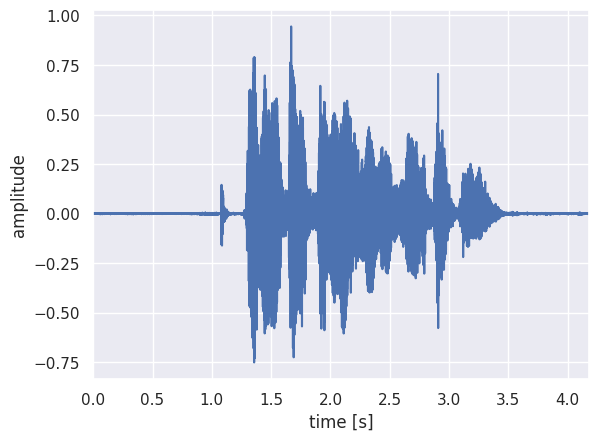

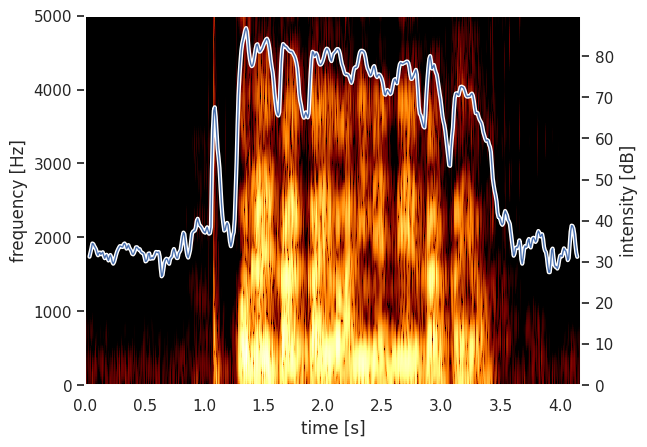

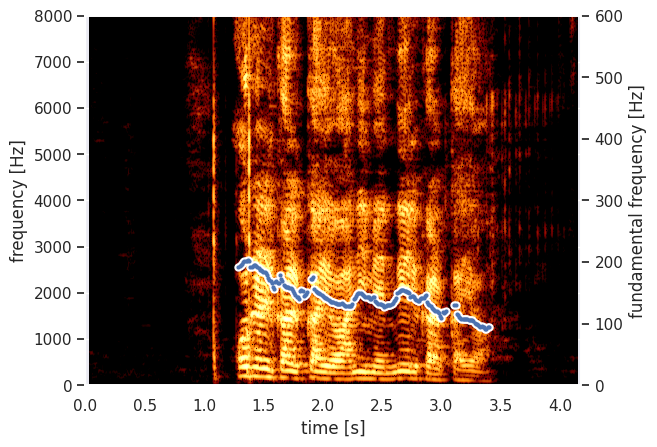

In [5]:
import parselmouth

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set() # Use seaborn's default style to make attractive graphs

# Plot nice figures using Python's "standard" matplotlib library
snd = parselmouth.Sound("./PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_014.wav")
plt.figure()
plt.plot(snd.xs(), snd.values.T)
plt.xlim([snd.xmin, snd.xmax])
plt.xlabel("time [s]")
plt.ylabel("amplitude")
plt.show() # or plt.savefig("sound.png"), or plt.savefig("sound.pdf")

def draw_spectrogram(spectrogram, dynamic_range=70):
    X, Y = spectrogram.x_grid(), spectrogram.y_grid()
    sg_db = 10 * np.log10(spectrogram.values)
    plt.pcolormesh(X, Y, sg_db, vmin=sg_db.max() - dynamic_range, cmap='afmhot')
    plt.ylim([spectrogram.ymin, spectrogram.ymax])
    plt.xlabel("time [s]")
    plt.ylabel("frequency [Hz]")

def draw_intensity(intensity):
    plt.plot(intensity.xs(), intensity.values.T, linewidth=3, color='w')
    plt.plot(intensity.xs(), intensity.values.T, linewidth=1)
    plt.grid(False)
    plt.ylim(0)
    plt.ylabel("intensity [dB]")

intensity = snd.to_intensity()
spectrogram = snd.to_spectrogram()
plt.figure()
draw_spectrogram(spectrogram)
plt.twinx()
draw_intensity(intensity)
plt.xlim([snd.xmin, snd.xmax])
plt.show() # or plt.savefig("spectrogram.pdf")

def draw_pitch(pitch):
    # Extract selected pitch contour, and
    # replace unvoiced samples by NaN to not plot
    pitch_values = pitch.selected_array['frequency']
    pitch_values[pitch_values==0] = np.nan
    plt.plot(pitch.xs(), pitch_values, 'o', markersize=5, color='w')
    plt.plot(pitch.xs(), pitch_values, 'o', markersize=2)
    plt.grid(False)
    plt.ylim(0, pitch.ceiling)
    plt.ylabel("fundamental frequency [Hz]")

pitch = snd.to_pitch()
# If desired, pre-emphasize the sound fragment before calculating the spectrogram
pre_emphasized_snd = snd.copy()
pre_emphasized_snd.pre_emphasize()
spectrogram = pre_emphasized_snd.to_spectrogram(window_length=0.03, maximum_frequency=8000)
plt.figure()
draw_spectrogram(spectrogram)
plt.twinx()
draw_pitch(pitch)
plt.xlim([snd.xmin, snd.xmax])
plt.show() # or plt.savefig("spectrogram_0.03.pdf")

In [3]:
from dataclasses import dataclass
from typing import Optional, Tuple
import torch
from transformers.file_utils import ModelOutput


@dataclass
class SpeechClassifierOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None
    hidden_states: Optional[Tuple[torch.FloatTensor]] = None
    attentions: Optional[Tuple[torch.FloatTensor]] = None

/home/willychen/miniconda3/envs/AUTOAI/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
import os
import json
import pandas as pd
import numpy as np
import string
import jiwer 
import argparse
import matplotlib.pyplot as plt

with open('../AUTO-AI/data/transcript.json', 'r') as f:
    transcripts = json.load(f)

for k, v in transcripts.items():
    v = v.translate(str.maketrans('', '', string.punctuation))
    transcripts[k] = v

with open('../AUTO-AI/data/voice_feature_dict.json', 'r') as f:
    voice_feature_dict = json.load(f)
    
with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)


for pat, files in voice_feature_dict.items():

    for ind, feats in files.items():

        if ind not in transcripts:
            continue

        if 148 <= int(pat.split(' ')[0].split('-')[1]) <= 298:
            cer = (jiwer.cer(transcripts[ind]*3, patient_dict[pat]['recordings'][ind]['whisper-small-korean']))
        else:
            cer = (jiwer.cer(transcripts[ind], patient_dict[pat]['recordings'][ind]['whisper-small-korean']))

        if cer >= 1:
            print(pat, ind, jiwer.cer(transcripts[ind], patient_dict[pat]['recordings'][ind]['whisper-small-korean']))
            print(transcripts[ind], '\n', patient_dict[pat]['recordings'][ind]['whisper-small-korean'])
        

1-169 015 4.933333333333334
엄마가 좋아요 아빠가 좋아요 
  "Oh my Israel, oh my Israel" "My Israel, my Israel" "Oh my Israel, my Israel"
1-198 NC 015 4.933333333333334
엄마가 좋아요 아빠가 좋아요 
  Omaga choayo apaga choayo omaga choayo apaga choayo omaga choayo apaga choayo


In [4]:
import os
import json
import pandas as pd
import numpy as np
import string
import jiwer 
import argparse
import matplotlib.pyplot as plt

classes = ['early', 'advance', 'normal']

prediction = {}

for gt, cas in enumerate(classes):
    with open(f'../AUTO-AI/prediction/{cas}.txt', 'r') as fp:
        lines = fp.readlines()
        for line in lines:
            line = line.replace('\n', '').strip()
            file = line.split(':')[:2]
            pred = int(line[-1])
            if file[0] not in prediction:
                prediction[file[0]] = {}
            prediction[file[0]][file[1]] = [gt, pred]

print(prediction)
        
parser = argparse.ArgumentParser()
parser.add_argument('--data_dir', '-d', default='../AUTO-AI/data')
parser.add_argument('--feature_path', default='voice_feature_dict.json')
parser.add_argument('--meta_path', default='metadata_dict.json')
parser.add_argument('--transcript_path', default='transcript.json')
parser.add_argument('--info_path', default='Korea_participants_raw_info.xlsx')

args = parser.parse_args()

with open('../AUTO-AI/data/voice_feature_dict.json', 'r') as f:
    voice_feature_dict = json.load(f)

with open('../AUTO-AI/data/metadata_dict.json', 'r') as f:
    patient_dict = json.load(f)

with open('../AUTO-AI/data/transcript.json', 'r') as f:
    transcripts = json.load(f)

for k, v in transcripts.items():
    v = v.translate(str.maketrans('', '', string.punctuation))
    transcripts[k] = v

df = pd.read_excel('../AUTO-AI/data/Korea_participants_raw_info.xlsx')
pat_to_label = df[['Study ID','Subgrouping']].set_index('Study ID').to_dict()['Subgrouping']
label_to_ind = {'Early stage PD':0, 'Advanced stage PD':1,'Healthy control':2}

# remove non-exist / wrong data from patient dict
voice_feature_dict.pop('1-509')

wrong = []
correct = []

feat_dict = {}
feature_names = list(voice_feature_dict['1-001']['014'].keys()) + ['Age'] + ['Sex'] + ['Words_per_Second'] + ['CER']
for pat, files in voice_feature_dict.items():
    # if pat not in prediction:
    #     continue
    feat_dict[pat] = {}
    pat_df = df.loc[df['Study ID'] == pat.split(' ')[0]]
    for ind, feats in files.items():
        # if ind not in prediction[pat]:
        #     continue
        feat_dict[pat][ind] = {}
        # audio features
        for i in range(5):
            feat_dict[pat][ind][feature_names[i]] = list(feats.values())[i]
        # Age
        feat_dict[pat][ind][feature_names[5]] = pat_df['Age at recording'].values[0]
        # Sex
        feat_dict[pat][ind][feature_names[6]] = (0 if pat_df['Sex'].values[0] == 'M' else 1)
        # Words per Second
        feat_dict[pat][ind][feature_names[7]] = len(transcripts[ind]) / patient_dict[pat]['recordings'][ind]['duration']
        # Word Error Rate (whisper small korean)
        feat_dict[pat][ind][feature_names[8]] = jiwer.cer(transcripts[ind], patient_dict[pat]['recordings'][ind]['whisper-small-korean'])
        # groundtruth
        # feat_dict[pat][ind]['gt'] = prediction[pat][ind][0]
        # predict
        # feat_dict[pat][ind]['pred'] = prediction[pat][ind][1]
        
        if (jiwer.cer(transcripts[ind], patient_dict[pat]['recordings'][ind]['whisper-small-korean'])) >= 10:
            print(pat, ind, jiwer.cer(transcripts[ind], patient_dict[pat]['recordings'][ind]['whisper-small-korean']), patient_dict[pat]['recordings'][ind]['whisper-small-korean'])
        
        # if prediction[pat][ind][0] == prediction[pat][ind][1]:
        #     correct.append(jiwer.cer(transcripts[ind], patient_dict[pat]['recordings'][ind]['whisper-small-korean']))
        # else:
        #     wrong.append(jiwer.cer(transcripts[ind], patient_dict[pat]['recordings'][ind]['whisper-small-korean']))
        
print(feat_dict)

# crr = [correct.count(0), correct.count(1)]
# wrr = [wrong.count(0), wrong.count(1)]

# print(crr)
# print(wrr)

# plt.figure()
# plt.title('Gender')
# plt.bar(['M','F'], crr, label='correct')
# plt.bar(['M','F'], wrr, bottom=crr, label='incorrect')
# plt.legend()

# plt.figure()
# plt.title('Words per second')
# age_dict = {'correct':np.array(correct), 'incorrect':np.array(wrong)}
# xs = np.hstack((np.zeros(len(correct)), np.ones(len(wrong))))
# print(xs)
# plt.scatter(xs, correct+wrong)
# # plt.yticks([1,2], age_dict.keys())
# plt.grid()


# plt.figure()
# plt.title('Word error rate')
# age_dict = {'correct':np.array(correct), 'incorrect':np.array(wrong)}
# plt.boxplot(age_dict.values(), vert=False)
# plt.yticks([1,2], age_dict.keys())
# plt.grid()


{'1-171': {'016': [0, 2]}, '1-403': {'019': [0, 0], '023': [0, 0], '014': [0, 0], '025': [0, 0], '024': [0, 0]}, '1-087': {'018': [0, 2]}, '1-455': {'023': [0, 0], '021': [0, 0], '018': [0, 0], '015': [0, 0]}, '1-496': {'024': [0, 0], '016': [0, 0], '021': [0, 0], '017': [0, 0], '014': [0, 0]}, '1-438': {'015': [0, 0], '017': [0, 0], '020': [0, 0], '021': [0, 0], '019': [0, 0]}, '1-142': {'017': [0, 0], '018': [0, 0]}, '1-033': {'017': [0, 0]}, '1-407': {'019': [0, 0], '021': [0, 0], '017': [0, 0]}, '1-437': {'018': [0, 0], '014': [0, 0], '025': [0, 0]}, '1-114': {'017': [0, 2], '015': [0, 2], '016': [0, 2]}, '1-100': {'018': [0, 0], '015': [0, 0], '016': [0, 0]}, '1-076': {'016': [0, 0]}, '1-096': {'015': [0, 1], '016': [0, 2], '014': [0, 0]}, '1-435': {'014': [0, 0], '016': [0, 0], '018': [0, 0], '015': [0, 0]}, '1-143': {'014': [0, 0], '016': [0, 0], '017': [0, 0]}, '1-072': {'017': [0, 0], '015': [0, 2]}, '1-107': {'018': [0, 2], '014': [0, 0], '015': [0, 0], '016': [0, 0], '017': 

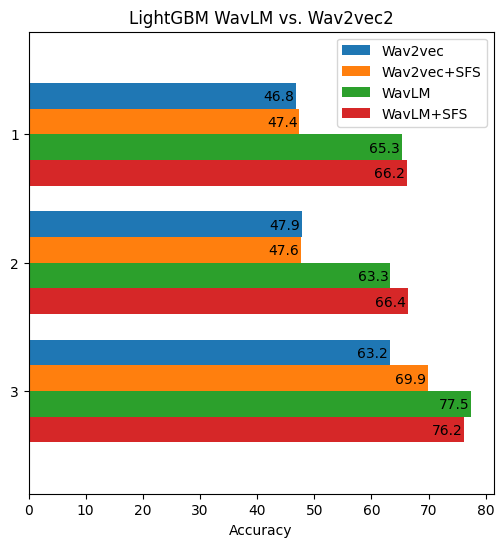

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6,6))

# Example data
people = (1, 2, 3)
y_pos = np.arange(len(people))
wav2vec_performance = [47.1, 47.3, 64.8]
wavlm_performance = [64.1, 63.2, 70.1]
wav2vec_sfs_performance = [46.9, 47.9, 72.5]
wavlm_sfs_performance = [62.4, 63.2, 73.5]
width = 0.2

wav2vec_performance = [46.8, 47.9, 63.2]
wavlm_performance = [65.3, 63.3, 77.5]
wav2vec_sfs_performance = [47.4, 47.6, 69.9]
wavlm_sfs_performance = [66.2, 66.4, 76.2]

ax.barh(y_pos - width*0.5, wav2vec_performance, height=width, align='center', label='Wav2vec')
ax.barh(y_pos + width*0.5, wav2vec_sfs_performance, height=width, align='center', label='Wav2vec+SFS')
ax.barh(y_pos + width*1.5, wavlm_performance, height=width, align='center', label='WavLM')
ax.barh(y_pos + width*2.5, wavlm_sfs_performance, height=width, align='center', label='WavLM+SFS')
ax.set_yticks(y_pos, labels=people)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Accuracy')
ax.set_title('LightGBM WavLM vs. Wav2vec2')
for i,j in zip(people,wavlm_performance):
    ax.text(j-3,i-width*3-0.04, str(j), ha='center', va='bottom')
for i,j in zip(people,wav2vec_sfs_performance):
    ax.text(j-3,i-width*4-0.04, str(j), ha='center', va='bottom')
for i,j in zip(people,wav2vec_performance):
    ax.text(j-3,i-width*5-0.04, str(j), ha='center', va='bottom')
for i,j in zip(people,wavlm_sfs_performance):
    ax.text(j-3,i-width*2-0.04, str(j), ha='center', va='bottom')
ax.set(yticks=y_pos + width, yticklabels=people, ylim=[2*width - 1, len(people)])
ax.legend()
plt.gca().invert_yaxis()

plt.show()

In [2]:
import torch
import torch.nn as nn
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss, MSELoss

from transformers.models.wav2vec2.modeling_wav2vec2 import (
    Wav2Vec2PreTrainedModel,
    Wav2Vec2Model
)


class Wav2Vec2ClassificationHead(nn.Module):
    """Head for wav2vec classification task."""

    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.final_dropout)
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, features, **kwargs):
        x = features
        x = self.dropout(x)
        x = self.dense(x)
        x = torch.tanh(x)
        x = self.dropout(x)
        x = self.out_proj(x)
        return x


class Wav2Vec2ForSpeechClassification(Wav2Vec2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.pooling_mode = config.pooling_mode
        self.config = config

        self.wav2vec2 = Wav2Vec2Model(config)
        self.classifier = Wav2Vec2ClassificationHead(config)

        self.init_weights()

    def freeze_feature_extractor(self):
        self.wav2vec2.feature_extractor._freeze_parameters()

    def merged_strategy(
            self,
            hidden_states,
            mode="mean"
    ):
        if mode == "mean":
            outputs = torch.mean(hidden_states, dim=1)
        elif mode == "sum":
            outputs = torch.sum(hidden_states, dim=1)
        elif mode == "max":
            outputs = torch.max(hidden_states, dim=1)[0]
        else:
            raise Exception(
                "The pooling method hasn't been defined! Your pooling mode must be one of these ['mean', 'sum', 'max']")

        return outputs

    def forward(
            self,
            input_values,
            attention_mask=None,
            output_attentions=None,
            output_hidden_states=None,
            return_dict=None,
            labels=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs = self.wav2vec2(
            input_values,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        hidden_states = outputs[0]
        hidden_states = self.merged_strategy(hidden_states, mode=self.pooling_mode)
        logits = self.classifier(hidden_states)

        loss = None
        if labels is not None:
            if self.config.problem_type is None:
                if self.num_labels == 1:
                    self.config.problem_type = "regression"
                elif self.num_labels > 1 and (labels.dtype == torch.long or labels.dtype == torch.int):
                    self.config.problem_type = "single_label_classification"
                else:
                    self.config.problem_type = "multi_label_classification"

            if self.config.problem_type == "regression":
                loss_fct = MSELoss()
                loss = loss_fct(logits.view(-1, self.num_labels), labels)
            elif self.config.problem_type == "single_label_classification":
                loss_fct = CrossEntropyLoss()
                loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            elif self.config.problem_type == "multi_label_classification":
                loss_fct = BCEWithLogitsLoss()
                loss = loss_fct(logits, labels)

        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return SpeechClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

In [3]:
import transformers

# Load model directly
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq, Wav2Vec2FeatureExtractor, AutoConfig

# processor = AutoProcessor.from_pretrained("steja/whisper-small-korean")
# model = AutoModelForSpeechSeq2Seq.from_pretrained("steja/whisper-small-korean")

from transformers import AutoFeatureExtractor, Wav2Vec2Processor, WavLMModel, WavLMForSequenceClassification, WavLMForXVector

# feature_extractor = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base-plus-sv")
# model = WavLMForXVector.from_pretrained("microsoft/wavlm-base-plus-sv")

processor = Wav2Vec2Processor.from_pretrained("kresnik/wav2vec2-large-xlsr-korean")

label_list = ['Early stage PD', 'Advanced stage PD','Healthy control']
num_labels = len(label_list)
config = AutoConfig.from_pretrained(
    "kresnik/wav2vec2-large-xlsr-korean",
    num_labels=num_labels,
    label2id={label: i for i, label in enumerate(label_list)},
    id2label={i: label for i, label in enumerate(label_list)},
    finetuning_task="wav2vec2_clf",
)
setattr(config, 'pooling_mode', 'mean')
model = Wav2Vec2ForSpeechClassification.from_pretrained("kresnik/wav2vec2-large-xlsr-korean", config=config)


/home/willychen/miniconda3/envs/AUTOAI/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of Wav2Vec2ForSpeechClassification were not initialized from the model checkpoint at kresnik/wav2vec2-large-xlsr-korean and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [1]:
import librosa
import torch
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

input_audio, sample_rate = librosa.load("./PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_015.wav",  sr=16000)

model_name = "kresnik/wav2vec2-large-xlsr-korean"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
model = Wav2Vec2Model.from_pretrained(model_name)

i = feature_extractor(input_audio, return_tensors="pt", sampling_rate=sample_rate)
with torch.no_grad():
  o = model(i.input_values)

last_hidden_state = o.last_hidden_state.squeeze().mean(dim=0).numpy()

print(last_hidden_state.shape)

/home/willychen/miniconda3/envs/AUTOAI/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/willychen/miniconda3/envs/AUTOAI/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at kresnik/wav2vec2-large-xlsr-korean and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


(1024,)


In [10]:
import librosa
import torch

audio_path = "./PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_015.wav"

audio_data, sample_rate = librosa.load(audio_path, sr=16000)

# input_features = processor(audio_data, sampling_rate=16000, return_tensors='pt')

# with torch.no_grad():
#     output = model(**input_features)
# last_hidden_states = output.last_hidden_state
# embeddings = output.embeddings

# print(last_hidden_states.shape)
# print(last_hidden_states.squeeze().mean(dim=0).shape)

# inputs = feature_extractor(audio_data, sampling_rate=16000, return_tensors="pt")

# with torch.no_grad():
#     logits = model(**inputs).logits

# print(logits.shape)

# inputs = feature_extractor(audio_data, sampling_rate=16000, return_tensors="pt")
# with torch.no_grad():
#     embeddings = model(**inputs).embeddings

# embeddings = torch.nn.functional.normalize(embeddings, dim=-1).cpu()
# print(embeddings.shape)

features = processor(audio_data, sampling_rate=processor.feature_extractor.sampling_rate, return_tensors="pt", padding=True)

input_values = features.input_values
attention_mask = features.attention_mask

with torch.no_grad():
    logits = model(input_values, attention_mask=attention_mask).logits 

pred_ids = torch.argmax(logits, dim=-1).numpy()
print(logits)

tensor([[-0.2082,  0.1540,  0.2066]])


In [5]:
import json
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

with open("embeddings_wavlm-sv.json", "r") as fp:
    input_embeddings = json.load(fp)

df = pd.read_excel('../AUTO-AI/data/Korea_participants_raw_info.xlsx')
pat_to_label = df[['Study ID','Subgrouping']].set_index('Study ID').to_dict()['Subgrouping']
label_to_ind = {'Early stage PD':0, 'Advanced stage PD':1,'Healthy control':2}
label = []
input_embeddings.pop("1-255")
for pat, v in input_embeddings.items():
    print(pat)
    for rec, val in v.items():
        label.append(label_to_ind[pat_to_label[pat.split(' ')[0]]])
#         print(rec, ':', len(val))
X = np.array([list(val) for k, v in input_embeddings.items() for rec, val in v.items()])
print(X.shape)

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a PCA instance: PCA for 2 components
pca = PCA(n_components=100)

# Fit on data
pca.fit(X_scaled)

# Transform the data
X_pca = pca.transform(X_scaled)
print("Original shape: ", X.shape)
print("Transformed shape:", X_pca.shape)


lda = LDA()
X_lda = lda.fit_transform(X_scaled, label)
print("Original shape: ", X.shape)
print("Transformed shape:", X_lda.shape)

1-001
1-002
1-003 NC
1-005
1-007
1-008
1-009 NC
1-010
1-012
1-013 NC
1-014
1-015 NC
1-016
1-017
1-019
1-020 NC
1-022 NC
1-023
1-024 NC
1-026 NC
1-027
1-028
1-030 NC
1-031
1-032
1-033
1-034 NC
1-039
1-040
1-042
1-045 NC
1-046
1-048
1-049 NC
1-051
1-052
1-054 NC
1-055
1-056 NC
1-057
1-058 NC
1-060 NC
1-061
1-062
1-063 NC
1-064
1-072
1-073
1-075 NC
1-076
1-077
1-078 NC
1-080
1-081 NC
1-083
1-085 NC
1-086
1-087
1-088 NC
1-092
1-093
1-096
1-097
1-099
1-100
1-102 NC
1-103
1-104
1-105
1-106
1-107
1-108
1-109 NC
1-110
1-111
1-113
1-114
1-115 NC
1-116
1-118
1-119
1-120
1-121 NC
1-123
1-125
1-126 NC
1-127
1-131
1-132
1-133
1-134 NC
1-135
1-136
1-138 NC
1-140 NC
1-142
1-143
1-146 NC
1-148
1-149 NC
1-150
1-151 NC
1-153 NC
1-156
1-157 NC
1-158
1-159 NC
1-164 NC
1-166 NC
1-167
1-168 NC
1-169
1-170
1-171
1-173
1-174
1-175
1-176 NC
1-178 NC
1-180 NC
1-181
1-182 NC
1-183
1-185 NC
1-186
1-187 NC
1-189
1-191
1-193
1-194 NC
1-196 NC
1-198 NC
1-201
1-202
1-204 NC
1-205
1-207
1-208
1-209
1-210
1-212 NC
1-21

In [6]:
import json
import torch
import librosa

from transformers import AutoFeatureExtractor, Wav2Vec2Processor, WavLMModel, WavLMForSequenceClassification, WavLMForXVector

with open('../AUTO-AI/data/voice_feature_dict.json', 'r') as f:
    voice_feature_dict = json.load(f)

with open("../AUTO-AI/data/metadata_dict.json", 'r') as f:
    patient_dict = json.load(f)

feature_extractor = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base-plus-sv")
model = WavLMForXVector.from_pretrained("microsoft/wavlm-base-plus-sv")

# model_name = "kresnik/wav2vec2-large-xlsr-korean"
# feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
# model = Wav2Vec2Model.from_pretrained(model_name)

data_dir = './PD/AudioKoreaDrKim'
def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-{}_'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'], 'NC' if 'NC' in pat else 'PD')
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0]+'.wav')

    return paths

input_embeddings = {}
for pat, val in patient_dict.items():
    input_embeddings[pat] = {}
    paths = data_to_path(val)
    print(pat)
    for path in paths:

        audio_data, sample_rate = librosa.load(path, sr=16000)

        inputs = feature_extractor(audio_data, sampling_rate=16000, return_tensors="pt")
        with torch.no_grad():
            embeddings = model(**inputs).embeddings

        embeddings = torch.nn.functional.normalize(embeddings, dim=-1).cpu()#.squeeze().mean(dim=0).numpy()
        input_embeddings[pat][path[-7:-4]] = embeddings.tolist()[0]

# input_embeddings = np.array(input_embeddings)
# print(input_embeddings.shape)

with open("embeddings_wavlm-sv.json", "w") as fp:
    json.dump(input_embeddings, fp)

Some weights of the model checkpoint at microsoft/wavlm-base-plus-sv were not used when initializing WavLMForXVector: ['wavlm.encoder.pos_conv_embed.conv.weight_g', 'wavlm.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMForXVector from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WavLMForXVector from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WavLMForXVector were not initialized from the model checkpoint at microsoft/wavlm-base-plus-sv and are newly initialized: ['wavlm.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wavlm.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a d

1-001
1-002
1-003 NC
1-005
1-007
1-008
1-009 NC
1-010
1-012
1-013 NC
1-014
1-015 NC
1-016
1-017
1-019
1-020 NC
1-022 NC
1-023
1-024 NC
1-026 NC
1-027
1-028
1-030 NC
1-031
1-032
1-033
1-034 NC
1-039
1-040
1-042
1-045 NC
1-046
1-048
1-049 NC
1-051
1-052
1-054 NC
1-055
1-056 NC
1-057
1-058 NC
1-060 NC
1-061
1-062
1-063 NC
1-064
1-072
1-073
1-075 NC
1-076
1-077
1-078 NC
1-080
1-081 NC
1-083
1-085 NC
1-086
1-087
1-088 NC
1-092
1-093
1-096
1-097
1-099
1-100
1-102 NC
1-103
1-104
1-105
1-106
1-107
1-108
1-109 NC
1-110
1-111
1-113
1-114
1-115 NC
1-116
1-118
1-119
1-120
1-121 NC
1-123
1-125
1-126 NC
1-127
1-131
1-132
1-133
1-134 NC
1-135
1-136
1-138 NC
1-140 NC
1-142
1-143
1-146 NC
1-148
1-149 NC
1-150
1-151 NC
1-153 NC
1-156
1-157 NC
1-158
1-159 NC
1-164 NC
1-166 NC
1-167
1-168 NC
1-169
1-170
1-171
1-173
1-174
1-175
1-176 NC
1-178 NC
1-180 NC
1-181
1-182 NC
1-183
1-185 NC
1-186
1-187 NC
1-189
1-191
1-193
1-194 NC
1-196 NC
1-198 NC
1-201
1-202
1-204 NC
1-205
1-207
1-208
1-209
1-210
1-212 NC
1-21

In [9]:
import os
import numpy as np
import json
import re

import soundfile as sf
import librosa

data_dir = './PD/AudioKoreaDrKim'

patient_dirs = sorted(os.listdir(data_dir))[1:-3]
print(patient_dirs)
print(len(patient_dirs))

patient_dict = {}
for patient in patient_dirs:
    patient_dir = os.path.join(data_dir, patient)
    patient_recs = os.listdir(patient_dir)
    [_, id, ord, age, gender, date, no] = patient_recs[0].split('-')
    patient_dict[patient] = {'id':id, 'ord':ord, 'age':age, 'gender':gender, 'date':date, 'recordings':{}}
    for rec in patient_recs:
        patient_dict[patient]['recordings'][(re.search('_(.*).wav', rec).group(1))]={}
        
        patient_dict[patient]['recordings'][(re.search('_(.*).wav', rec).group(1))]['duration'] = librosa.get_duration(path=os.path.join(patient_dir, rec))

        audio_data, sample_rate = librosa.load(os.path.join(patient_dir, rec), sr=16000)

        input_features = processor(audio_data, sampling_rate=sample_rate, return_tensors="pt").input_features
        predicted_ids = model.generate(input_features)

        transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
        patient_dict[patient]['recordings'][(re.search('_(.*).wav', rec).group(1))]['whisper-small-korean'] = transcription
    print(patient_dict[patient]['recordings'])

print(patient_dict)
with open('./metadata_dict.json', 'w') as f:
    json.dump(patient_dict, f)

# y_i, sr_i = librosa.load(os.path.join(data_dir, 'recording_{}.wav')), sr=44100)
"""
 "1-509": {"id": "509", "ord": "YYO", "age": "52", "gender": "F", "date": "20221021", "recordings": {"019": {"duration": 11.264, "whisper-small-korean": "\uc2a4\ub2e4\ub4ec\uc5b4\uc9c4 \ub4ef\ud55c \uc644\ub9cc\ud568\uacfc \uae4e\uc544\ub193\uc740 \ub4ef\ud55c \ubfb0\uc871\ud568\uc774 \uc5b4\uc6b0\ub7ec\uc9c4 \uc0c1\ub4f1\uc131\uc774\ub97c \ub530\ub77c \uc624\ub974\ub2e4 \ubcf4\uba74 \uc808\ub85c \uac10\ud0c4\uc744 \ud488\uc744 \uc218\uac00 \uc5c6\uac8c \ub41c\ub2e4"}, "016": {"duration": 2.986666666666667, "whisper-small-korean": "\uc6b0\ub9ac \ub098\ub77c\uc758 \uac00\uc744\uc740 \ucc38\uc73c\ub85c \uc544\ub984\ub2f5\ub2e4"}, "015": {"duration": 2.816, "whisper-small-korean": "\uc5c4\ub9c8\uac00 \uc88b\uc544\uc694 \uc544\ube60\uac00 \uc88b\uc544\uc694"}, "020": {"duration": 11.690666666666667, "whisper-small-korean": "\ubd89\uc740\uc0c9 \ud478\ub978\uc0c9 \ub178\ub780\uc0c9 \ub4f1\uc758 \uc5ec\ub7ec \uac00\uc9c0 \uc0c9\uae54\ub4e4\uc774 \uc5b4\uc6b0\ub7ec\uc838 \ud0c0\ub294 \ub4ef\ud55c \uac10\ub3d9\uc744 \uc8fc\uba70 \ub098\uc544\uac00 \uc2e0\ube44\ub86d\uae30\uae4c\uc9c0 \ud558\ub2e4 \uc232\uc18d\uc5d0 \ub204\uc6cc\uc11c \ud558\ub298\uc744 \ubc14\ub77c\ubcf4\ub77c"}, "018": {"duration": 6.229333333333333, "whisper-small-korean": "\ubb34\uc5c7\ubcf4\ub2e4\ub3c4 \uc0b0\uc5d0 \uc624\ub97c \ub54c\ub294 \ub354\uc6b1 \ub354 \uadf8 \ube7c\uc5b4\ub09c \uc544\ub984\ub2e4\uc6c0\uc774 \ub290\uaef4\uc9c4\ub2e4"}, "022": {"duration": 15.445333333333334, "whisper-small-korean": "\uc0c8\ubcbd \ub3d9\uc774\ud130 \uc624\ub974\uc790 \ud558\ub298\uc740 \uc5f4\uae30\uad6c\uac00 \uc11c\uc11c\ud788 \ub5a0\uc624\ub974\uae30 \uc2dc\uc791\ud588\ub2e4 \uad6c\ub984\ucc98\ub7fc \uac00\ubccd\uac8c \ub465\uc2e4\ub465\uc2e0 \ub5a0\ub2e4\ub2c8\ub294 \uc5f4\uae30\uad6c\ub97c \ubcf4\uc790 \uc774 \ub9c8\uce58 \uc608\uc05c \uadf8\ub9bc \uc5fd\uc11c \uac19\uc558\ub2e4"}, "025": {"duration": 15.957333333333333, "whisper-small-korean": "\uace0\uc591\uc774\ub294 \ub610\ud55c \ub9f9\uc218\uc758 \uc0c1\uc9d5\uc774\uae30\ub3c4 \ud588\ub2e4 \uace0\uc591\uc774\ub294 \ud638\ub791\uc774 \ud45c\ubc94 \ub4f1 \uc790\ub3c5\ud55c \ub9f9\uc218\ub4e4\uacfc \ud568\uaed8 \uace0\uc591\uc774\uacfc \uc18d\ud55c\ub2e4 \ub2e4\ub9cc \uadf8\ub4e4 \uc911 \uac00\uc7a5 \uc791\uc544\uc11c \uc778\uac04\uc774 \uae38\ub300\ub9b4 \uc218 \uc788\uc5c8\uc744 \ubfd0\uc774\ub2e4"}, "024": {"duration": 13.056, "whisper-small-korean": "\uac70\ubd81\uc774\ub294 300\uc0b4 \uc774\uc0c1\uc744 \uc0b4\uc544\uc11c \uc61b \uc61b\ub0a0\ubd80\ud130 \uc7a5\uc218\ub97c \uc0c1\uc9d5\ud558\ub294 \ub3d9\ubb3c\ub85c \uc5ec\uaca8\uc838\uc654\ub2e4 \uac70\ubd81\uc774\ub294 \ub2e4\ub978 \ub3d9\ubb3c\ub4e4\uc5d0 \ube44\ud574 \ub178\uc544\uc758 \uc18d\ub3c4\ub3c4 \ub290\ub9b0 \uac83\uc73c\ub85c \ubc1d\ud600\uc84c\ub2e4"}, "021": {"duration": 13.738666666666667, "whisper-small-korean": "\uc30d\uc30d\uc774 \uc9dd \uc9c0\uc5b4\uc838 \uc788\ub294 \ub4ef\ud55c \ud770 \uad6c\ub984 \ub192\uc740 \ud30c\ub780 \ud558\ub298\uc744 \uccd0\ub2e4\ubcf4\uace0 \uc788\ub178\ub77c\uba74 \uacfc\uc5f0 \uc608\ubd80\ud130 \uac00\uc744\uc744 \uccad\uace0\ub9c8\ube44\uc758 \uacc4\uc808\uc774\ub77c \uc77c\uceeb\ub294 \uc774\uc720\ub97c \uc54c\uac8c \ub420 \uac83\ub9cc \uac19\ub2e4"}, "014": {"duration": 3.072, "whisper-small-korean": "\uc624\ub298 \uac08\uae4c\uc694 \uc544\ub2c8\uba74 \ub0b4\uc77c \uac08\uae4c\uc694"}, "017": {"duration": 6.314666666666667, "whisper-small-korean": "\uac00\uc744\uc740 \uc624\uace1\ubc31\uacfc \ub4f1 \uba39\uac70\ub9ac\uac00 \ud48d\ubd80\ud558\uae30 \ub54c\ubb38\uc5d0 \uacb0\uc2e4\uc758 \uacc4\uc808\uc774\ub77c\uace0\ub3c4 \ud55c\ub2e4"}, "023": {"duration": 12.544, "whisper-small-korean": "\uc804 \uc138\uacc4\uc801\uc73c\ub85c \uae30\ud6c4 \ubcc0\ud654\ub85c \uc778\ud574 \ud3c9\uade0 \uae30\uc628\uc774 \uc0c1\uc2b9\ud558\uace0 \uc788\uc2b5\ub2c8\ub2e4 \uc774\uc5d0 \ub530\ub77c\uc11c \ud64d\uc218 \uac10\uc74c \ud574\uc218\uba74 \uc0c1\uc2b9 \ub4f1 \uc790\uc5f0 \uc7ac\ud574\uac00 \uc790\uc8fc \ubc1c\uc0dd\ud558\uace0 \uc788\uc2b5\ub2c8\ub2e4"}}},
"""

['1-001', '1-002', '1-003 NC', '1-005', '1-007', '1-008', '1-009 NC', '1-010', '1-012', '1-013 NC', '1-014', '1-015 NC', '1-016', '1-017', '1-019', '1-020 NC', '1-022 NC', '1-023', '1-024 NC', '1-026 NC', '1-027', '1-028', '1-030 NC', '1-031', '1-032', '1-033', '1-034 NC', '1-039', '1-040', '1-042', '1-045 NC', '1-046', '1-048', '1-049 NC', '1-051', '1-052', '1-054 NC', '1-055', '1-056 NC', '1-057', '1-058 NC', '1-060 NC', '1-061', '1-062', '1-063 NC', '1-064', '1-072', '1-073', '1-075 NC', '1-076', '1-077', '1-078 NC', '1-080', '1-081 NC', '1-083', '1-085 NC', '1-086', '1-087', '1-088 NC', '1-092', '1-093', '1-096', '1-097', '1-099', '1-100', '1-102 NC', '1-103', '1-104', '1-105', '1-106', '1-107', '1-108', '1-109 NC', '1-110', '1-111', '1-113', '1-114', '1-115 NC', '1-116', '1-118', '1-119', '1-120', '1-121 NC', '1-123', '1-125', '1-126 NC', '1-127', '1-131', '1-132', '1-133', '1-134 NC', '1-135', '1-136', '1-138 NC', '1-140 NC', '1-142', '1-143', '1-146 NC', '1-148', '1-149 NC', '1-

KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import json
import pandas as pd

import librosa

from matplotlib import pyplot as plt

with open('./metadata.json', 'r') as f:
    patient_dict = json.load(f)

#plot duration distributions
durations = {}

for pat, info in patient_dict.items():
    if int(info['id']) < 148:
        continue
    if int(info['id']) > 298:
        break
    for wav in info['recordings']:
        wav_path, duration = wav.split(':')
        wav_path = wav_path[:-4]
        if float(duration) < 5:
            print(pat)
        if wav_path in durations:
            durations[wav_path].append(float(duration))
        else:
            durations[wav_path] = [float(duration)]

print(durations)
paragraphs = list(durations.keys())

plt.figure(figsize=(10,10))
plt.title('Duration for patient 1-299 to 1-510')
ylabs, duras = [],[]
for tp, dura in sorted(durations.items()):
    if len(dura) > 1 and tp not in {'PD_019','PD_020','PD_021','PD_022','PD_023','PD_024','PD_025', 'NC_019','NC_020','NC_021','NC_022','NC_023','NC_024','NC_025'}:
        duras.append(dura)
        ylabs.append(tp)
plt.boxplot(duras, vert=False)
plt.yticks(ticks=np.arange(len(ylabs))+1, labels=ylabs)
plt.grid()
plt.xlabel('Seconds (s)')
# plt.close()


"""
# find pat with 'ET','MSA','PT'
durations = {}
types = []
for pat, info in patient_dict.items():
    for wav in info['recordings']:
        wav_path, duration = wav.split(':')
        wav_path = wav_path[:-4]
        if float(duration) > 100:
            print(pat)
        types += [wav_path]
        # if wav_path.startswith('ET'):
        #     print(pat)
        if wav_path in durations:
            durations[wav_path].append(float(duration))
        else:
            durations[wav_path] = [float(duration)]
            
uq, ct = np.unique(types, return_counts=True)
for u, c in zip(uq, ct):
    print(u, ':', c)
"""


"""# age gender
gen_age_list = []
for pat, info in patient_dict.items():
    gen_age_list += [[int(info['age']), info['gender'], 'NC' if 'NC' in pat else 'PD']]
df = pd.DataFrame(gen_age_list, columns=['age', 'type', 'gender'])
bins = np.arange(1, 10) * 10
df['category'] = np.digitize(df.age, bins, right=True)
counts = df.groupby(['category', 'gender', 'type']).age.count().unstack().unstack()
print(counts)
ax = counts.plot(kind='bar', stacked=True)
bins = np.append(bins, [100])
print(bins)
age_range = [str(bins[i-1])+'~'+str(bins[i])  for i in range(1, len(bins)-1)]
ax.set_xticklabels(age_range)
ax.set_title('Age Gender Type')
ax.set_ylabel('Count')
ax.set_xlabel('Age')
"""



""" show num of PD vs NC
# diff = {} 
# for pat, info in patient_dict.items():
#     tp = info['recordings'][0].split('_')[0]
#     if tp in diff:
#         diff[tp]+=1
#     else:
#         diff[tp] = 1
# print(diff)
"""



In [19]:
import os
import json
import numpy as np

from pdmodel.voiceFeatureExtraction import new_audio_feature_without_filter, new_pitch_feature_without_filter

data_dir = './PD/AudioKoreaDrKim'

with open('./metadata.json', 'r') as f:
    patient_dict = json.load(f)

def data_to_path(data):
    paths = []
    prefix = '{}/{}/{}-{}-{}-{}-{}-'.format(data_dir, pat, pat.split(' ')[0], data['ord'], data['age'], data['gender'], data['date'])
    for rec in data['recordings']:
        paths.append(prefix+rec.split(':')[0])

    return paths

# voice_feature = {'PD':{'average_volume':[], 'volume_change':[], 'pause_percentage':[], 'average_pitch':[], 'pitch_change':[]},
#                  'NC':{'average_volume':[], 'volume_change':[], 'pause_percentage':[], 'average_pitch':[], 'pitch_change':[]}}

voice_feature = {}

for pat, val in patient_dict.items():
    voice_feature[pat] = {}
    paths = data_to_path(val)
    print(pat)
    for path in paths:
        
        average_volume, volume_change, pause_percentage, = new_audio_feature_without_filter(path)
        average_pitch, pitch_change, = new_pitch_feature_without_filter(path)
        # if 'NC' not in pat:
        #     voice_feature['PD']['average_volume'].append(average_volume)
        #     voice_feature['PD']['volume_change'].append(volume_change)
        #     voice_feature['PD']['pause_percentage'].append(pause_percentage)
        #     voice_feature['PD']['average_pitch'].append(average_pitch)
        #     voice_feature['PD']['pitch_change'].append(pitch_change)
        # else:
        #     voice_feature['NC']['average_volume'].append(average_volume)
        #     voice_feature['NC']['volume_change'].append(volume_change)
        #     voice_feature['NC']['pause_percentage'].append(pause_percentage)
        #     voice_feature['NC']['average_pitch'].append(average_pitch)
        #     voice_feature['NC']['pitch_change'].append(pitch_change)    
        wav_no = path[-7:-4]
        voice_feature[pat][wav_no] = ({'average_volume':average_volume, 'volume_change':volume_change, 'pause_percentage':pause_percentage, 'average_pitch':average_pitch, 'pitch_change':pitch_change})

with open('./voice_feature_dict.json', 'w') as f:
    json.dump(voice_feature, f)

1-001
1-002
1-003 NC
1-005
1-007
1-008
1-009 NC
1-010
1-012
1-013 NC
1-014
1-015 NC
1-016
1-017
1-019
1-020 NC
1-022 NC
1-023
1-024 NC
1-026 NC
1-027
1-028
1-030 NC
1-031
1-032
1-033
1-034 NC
1-039
1-040
1-042
1-045 NC
1-046
1-048
1-049 NC
1-051
1-052
1-054 NC
1-055
1-056 NC
1-057
1-058 NC
1-060 NC
1-061
1-062
1-063 NC
1-064
1-072
1-073
1-075 NC
1-076
1-077
1-078 NC
1-080
1-081 NC
1-083
1-085 NC
1-086
1-087
1-088 NC
1-092
1-093
1-096
1-097
1-099
1-100
1-102 NC
1-103
1-104
1-105
1-106
1-107
1-108
1-109 NC
1-110
1-111
1-113
1-114
1-115 NC
1-116
1-118
1-119
1-120
1-121 NC
1-123
1-125
1-126 NC
1-127
1-131
1-132
1-133
1-134 NC
1-135
1-136
1-138 NC
1-140 NC
1-142
1-143
1-146 NC
1-148
1-149 NC
1-150
1-151 NC
1-153 NC
1-156
1-157 NC
1-158
1-159 NC
1-164 NC
1-166 NC
1-167
1-168 NC
1-169
1-170
1-171
1-173
1-174
1-175
1-176 NC
1-178 NC
1-180 NC
1-181
1-182 NC
1-183
1-185 NC
1-186
1-187 NC
1-189
1-191
1-193
1-194 NC
1-196 NC
1-198 NC
1-201
1-202
1-204 NC
1-205
1-207
1-208
1-209
1-210
1-212 NC
1-21

dict_keys(['1-001', '1-002', '1-003 NC', '1-005', '1-007', '1-008', '1-009 NC', '1-010', '1-012', '1-013 NC', '1-014', '1-015 NC', '1-016', '1-017', '1-019', '1-020 NC', '1-022 NC', '1-023', '1-024 NC', '1-026 NC', '1-027', '1-028', '1-030 NC', '1-031', '1-032', '1-033', '1-034 NC', '1-039', '1-040', '1-042', '1-045 NC', '1-046', '1-048', '1-049 NC', '1-051', '1-052', '1-054 NC', '1-055', '1-056 NC', '1-057', '1-058 NC', '1-060 NC', '1-061', '1-062', '1-063 NC', '1-064', '1-072', '1-073', '1-075 NC', '1-076', '1-077', '1-078 NC', '1-080', '1-081 NC', '1-083', '1-085 NC', '1-086', '1-087', '1-088 NC', '1-092', '1-093', '1-096', '1-097', '1-099', '1-100', '1-102 NC', '1-103', '1-104', '1-105', '1-106', '1-107', '1-108', '1-109 NC', '1-110', '1-111', '1-113', '1-114', '1-115 NC', '1-116', '1-118', '1-119', '1-120', '1-121 NC', '1-123', '1-125', '1-126 NC', '1-127', '1-131', '1-132', '1-133', '1-134 NC', '1-135', '1-136', '1-138 NC', '1-140 NC', '1-142', '1-143', '1-146 NC', '1-148', '1-14

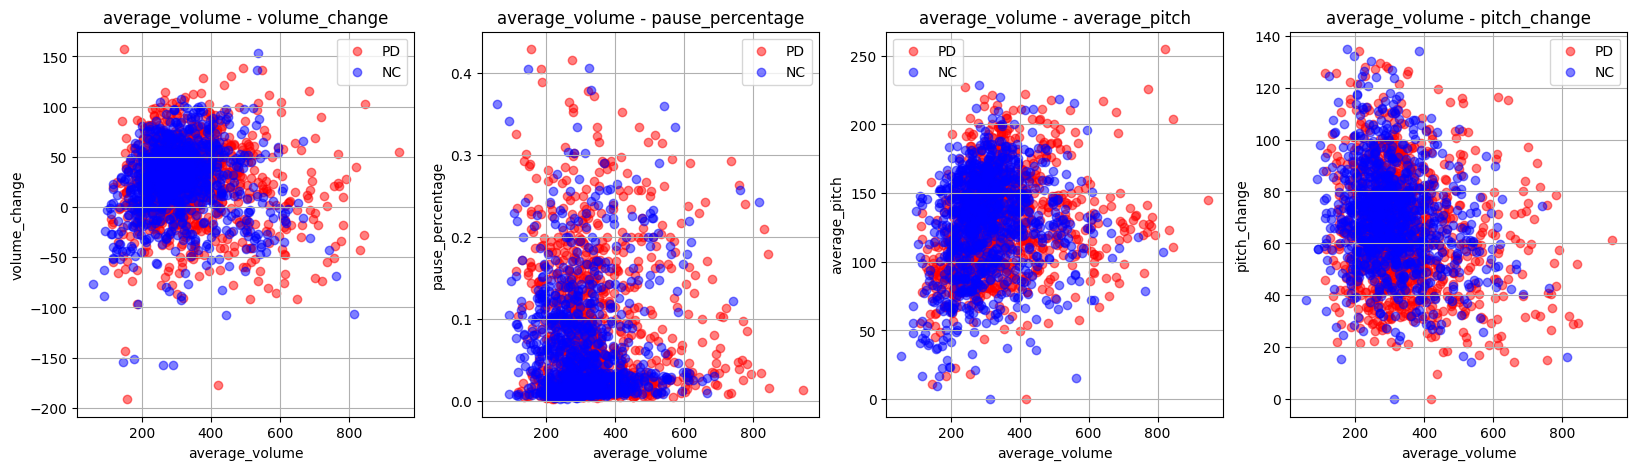

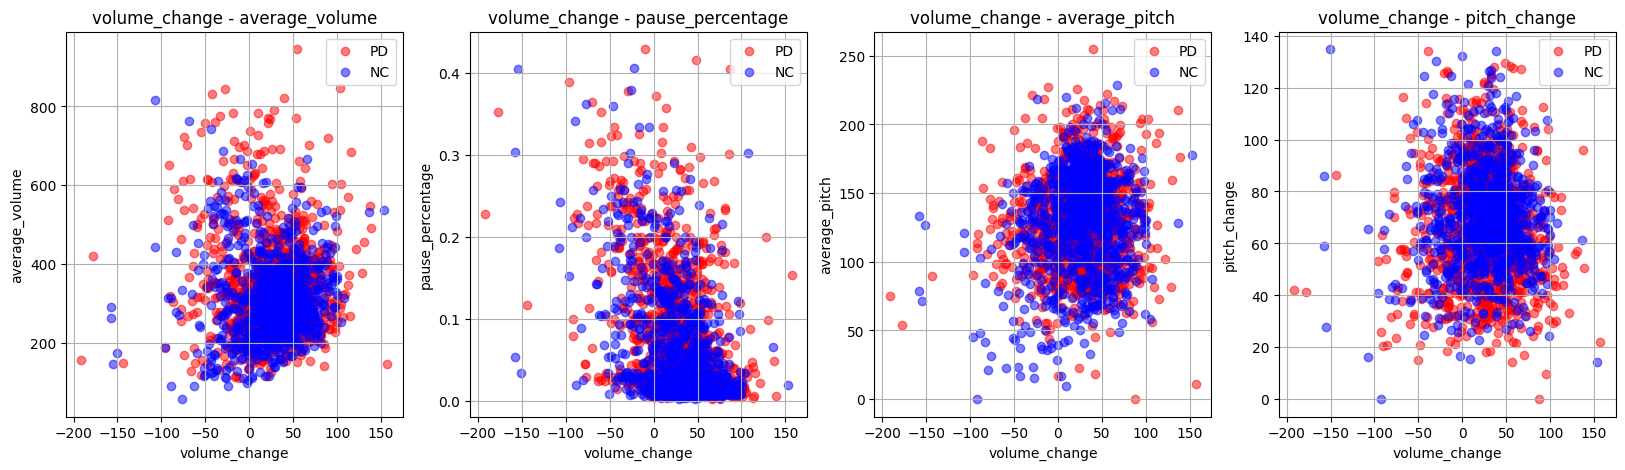

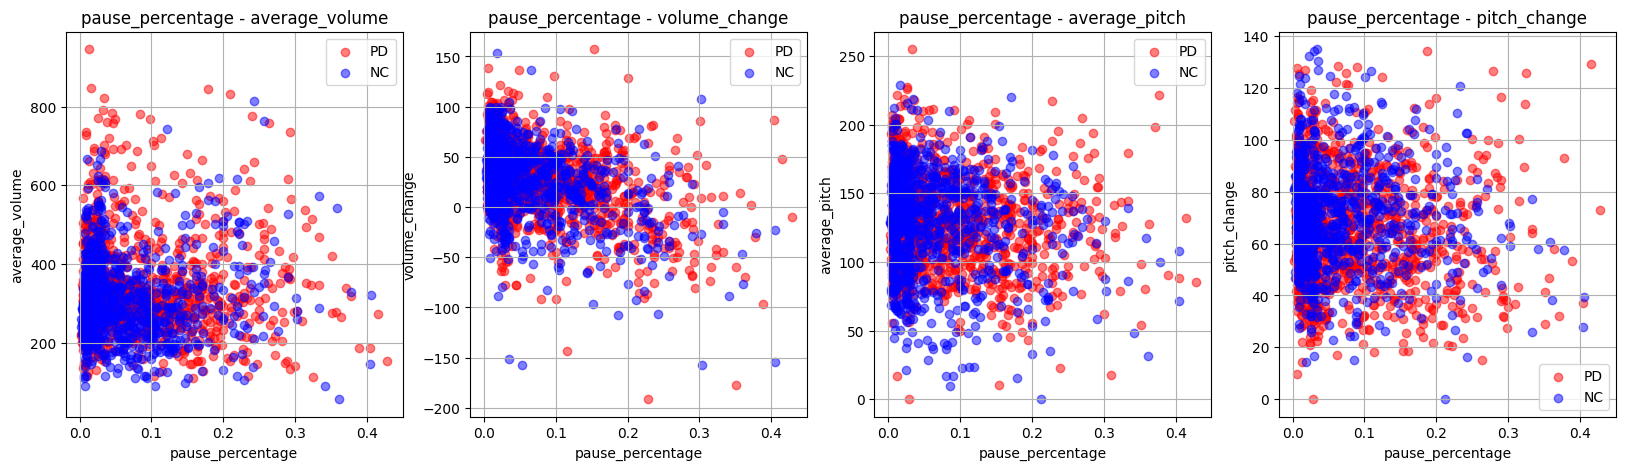

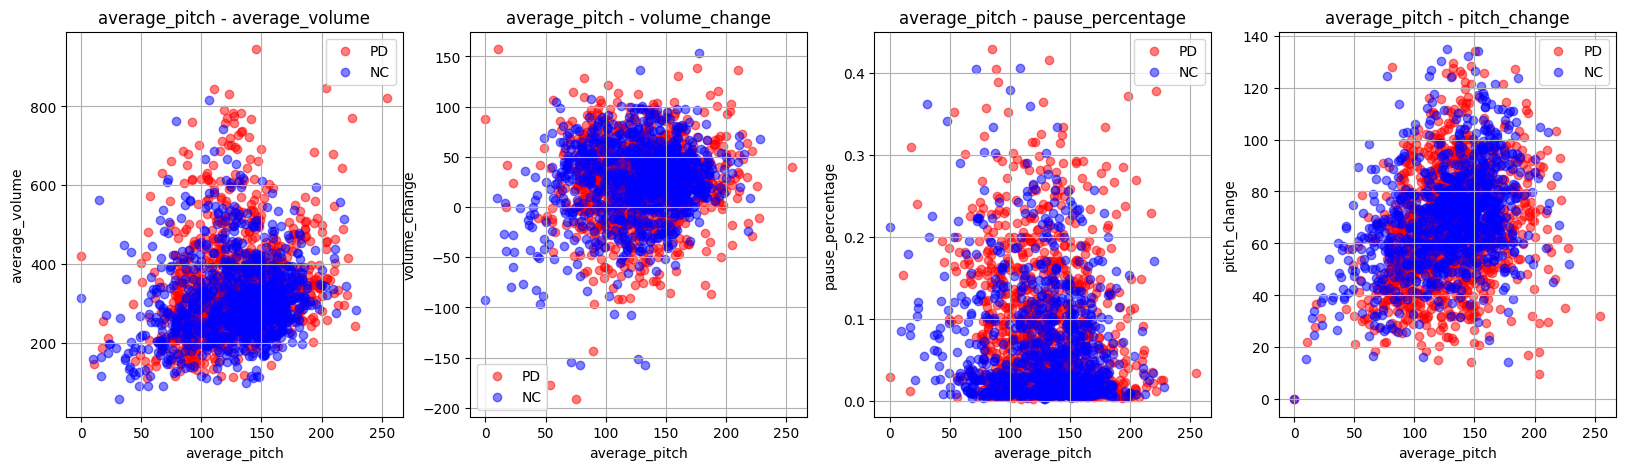

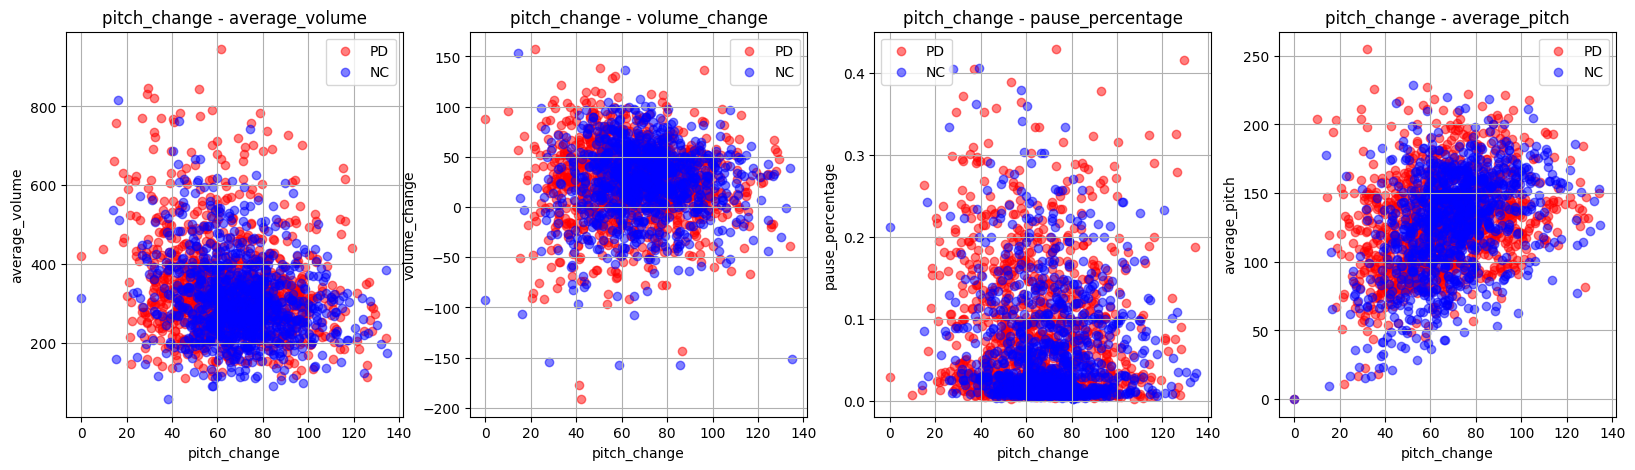

In [30]:
import os
import json
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

with open('./metadata.json', 'r') as f:
    patient_dict = json.load(f)

patient_list = patient_dict.keys()
print(patient_list)
# with open('./voice_feature_dict.json', 'r') as f:
    # voice_feature = json.load(f)

with open('./voice_feature.json', 'r') as f:
    voice_feature = json.load(f)
    
print(len(voice_feature['PD']['average_volume'] + voice_feature['NC']['average_volume']))
print(voice_feature['NC'])

features = ['average_volume', 'volume_change', 'pause_percentage', 'average_pitch', 'pitch_change']

for i in range(len(features)):
    cnt = 1
    plt.subplots(1, 4, figsize=(20,5))
    for j in range(len(features)):  
        if i == j:
            continue      
        plt.subplot(1, 4, cnt)
        plt.title('{} - {}'.format(features[i], features[j]))
        plt.scatter(voice_feature['PD'][features[i]], voice_feature['PD'][features[j]], color='red', alpha=0.5, label='PD')
        plt.scatter(voice_feature['NC'][features[i]], voice_feature['NC'][features[j]], color='blue', alpha=0.5, label='NC')
        plt.grid()
        plt.legend()
        plt.xlabel(features[i])
        plt.ylabel(features[j])
        cnt += 1


In [27]:
import os
import json
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

df = pd.read_excel('../AUTO-AI/data/Korea_participants_raw_info.xlsx')

df[['Study ID','Subgrouping']].set_index('Study ID').to_dict()['Subgrouping']['1-010']

'Early stage PD'

In [7]:
import librosa

audio_path = "./PD/AudioKoreaDrKim/1-001/1-001-LBU-70-M-20220704-PD_014.wav"

audio_data, sample_rate = librosa.load(audio_path, sr=16000)

input_features = processor(audio_data, sampling_rate=sample_rate, return_tensors="pt").input_features
predicted_ids = model.generate(input_features)

transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
transcription

'오를 갈까요 아니면 내일 갈까요'

1-180 NC
0.4869272640130927
0.7363666251593809


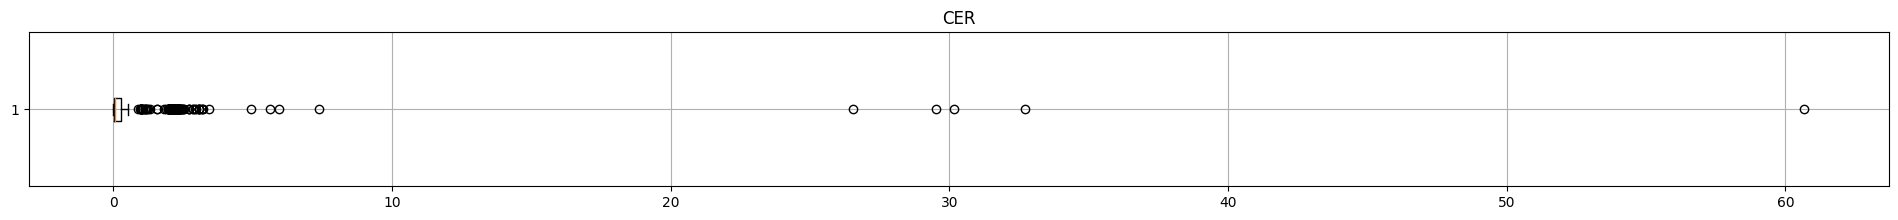

In [25]:
import os
import json
import string
import numpy as np

import jiwer
from matplotlib import pyplot as plt

with open('../AUTO-AI/data/transcript.json', 'r') as f:
    transcripts = json.load(f)

with open('./metadata_dict.json', 'r') as f:
    meta_dict = json.load(f)

for k, v in transcripts.items():
    v = v.translate(str.maketrans('', '', string.punctuation))
    transcripts[k] = v
    # print(v, len(v))

# print(transcripts['014'])
# print(meta_dict['1-001']['recordings']['014']['whisper-small-korean'])

meta_dict.pop('1-255')
cers = {"PD":[], "NC":[]}
for pat, val in meta_dict.items():
    # print(pat)
    for ind, dat in meta_dict[pat]['recordings'].items():
        # print(dat['whisper-small-korean'])
        cer = jiwer.cer(transcripts[ind], dat['whisper-small-korean'])
        if cer > 40:
            print(pat)
        cers['NC' if 'NC' in pat else 'PD'].append(cer)


print(np.array(cers['PD']).mean())
print(np.array(cers['NC']).mean())

plt.figure(figsize=(24,2))
plt.title('CER')
plt.boxplot(np.array(cers['NC']), vert=False)
# plt.boxplot(np.array(cers['NC']), vert=False)
# plt.yticks(ticks=np.arange(len(ylabs))+1, labels=ylabs)
plt.grid()
# plt.savefig('./cers.png')
# reference = transcripts['014']
# hypothesis = meta_dict['1-001']['recordings']['014']['whisper-small-korean']

# cer = jiwer.cer(
#     reference, 
#     hypothesis
# )

# print(f"Word Error Rate: {cer:.2f}")
